### Simulating data with or without criterion fluctuations
- With:
    as usual (see hmfc.py)
- Without:
    _sample function returns zeros for the latent states + true model has hyperparameter for a and sigma_sq
    such that sampled values for both parameters are very close to zero.
    

### Estimating criterion fluctuations or not
- If estimated:
    as usual (see hmfc.py)
- If not estimated: 
    Init model has hyperparameters for a and sigma_sq (a0, nu_a, alpha, and beta) such that sampled values for both parameters are very close to zero.
    We don't update the a0, nu_a, alpha, and beta by removing these steps in the _gibbs_steps_global.
    In gibbs_step_states we don't estimate the latent state but instead return a sequence of zeros.



In [13]:
import equinox as eqx
import jax
import jax.numpy as jnp
import jax.random as jr
from jax.nn import sigmoid
from jaxtyping import Float, Array
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import pandas as pd
import seaborn as sns
from fastprogress import progress_bar
from scipy.stats import spearmanr
import numpy as np
from scipy.stats import norm


from typing import Union
from jax import vmap, lax
from functools import partial

from tensorflow_probability.substrates import jax as tfp
tfd = tfp.distributions
from hmfc.gibbs import gibbs_step_local_params, random_walk_mh, _gibbs_step_global_weights, _gibbs_step_global_weights_var, _gibbs_step_global_bias_var, _gibbs_step_global_ar, _gibbs_step_global_mu_sigmasq, _gibbs_step_global_beta_sigmasq, gibbs_step_global_params, _pg_sample, gibbs_step_pg
from hmfc.lds import lds_info_sample, _sample_info_gaussian
from hmfc.utils import convert_mean_to_std_ig_params
from hmfc.constants import A_MAX, SIGMA_A_MAX, PG_TRUNC, SIGMASQ0


sns.set_theme(style="ticks", context="paper",
        rc={"font.size": 24,
            "axes.titlesize": 23,
            "axes.labelsize": 23,
            "lines.linewidth": 1.5,
            "xtick.labelsize": 18,
            "ytick.labelsize": 18,
            "xtick.major.size": 5,
            "ytick.major.size": 5,
            "xtick.minor.size": 2,
            "ytick.minor.size": 2,
            "axes.spines.right": False,
            "axes.spines.top": False
            })

### Model

In [14]:
class HierarchicalBernoulliLDS(eqx.Module):
    r"""
    Implementation of the model.
    """
    # Hyperparameters of the prior distributions
    log_lambda_mu : Float = 3.0               # rate of the exponential prior on mu (mean of inverse gamma prior for sigmasq of latent states)
    log_lambda_beta  : Float = 3.0            # rate of the exponential prior on beta (scale of inverse gamma prior for sigmasq of latent states)
    
    # Global parameters of the model
    mu_w       : Float[Array, "num_inputs"]   # mean normal for input weights
    log_sigma_w  : Float[Array, "num_inputs"] # sd normal for input weights
    logit_mu_a : Float = 10.0                 # mean truncated normal for autoregressive coefficients (latent states) in unconstrained form (allows HMC)
    log_sigma_a  : Float = -1.0               # sd truncated normal for autoregressive coefficient (latent states) in unconstrained form
    log_sigma_mu_x : Float = -1.0             # sd normal for mu_x
    log_mu_sigmasq: Float = -2.3              # log of the mean of sigmasq (variance of latent states)
    log_beta_sigmasq: Float = -2.3            # log of the scale of sigmasq (variance of latent states)

    def __init__(self, 
                 num_inputs : int,
                 mu_a : float = 0.99, 
                 sigma_a : float = 0.1, 
                 mu_w: Union[float, Float[Array, "num_inputs"]] = 0.0, 
                 sigma_w: Union[float, Float[Array, "num_inputs"]] = 1.0,
                 mu_sigmasq: float = 0.1, 
                 beta_sigmasq: float = 0.1, 
                 sigma_mu_x: float = 1.0, 
                 lambda_mu: float = 10., 
                 lambda_beta: float = 10.):
        
        # Set the hyperparameters
        self.log_lambda_mu = jnp.log(lambda_mu)
        self.log_lambda_beta = jnp.log(lambda_beta)
        
        # Set the global parameters
        self.logit_mu_a = jnp.log(mu_a / (1 - mu_a))
        self.log_sigma_a = jnp.log(sigma_a)
        self.mu_w = mu_w if isinstance(mu_w, jnp.ndarray) else jnp.full((num_inputs,), mu_w)
        self.log_sigma_w = jnp.log(sigma_w) if isinstance(sigma_w, jnp.ndarray) else jnp.full((num_inputs,), jnp.log(sigma_w))
        self.log_sigma_mu_x = jnp.log(sigma_mu_x)
        self.log_mu_sigmasq = jnp.log(mu_sigmasq)
        self.log_beta_sigmasq = jnp.log(beta_sigmasq)

    @property
    def num_inputs(self):
        return self.mu_w.shape[0]
    
    @property
    def lambda_mu(self):
        return jnp.exp(self.log_lambda_mu)
    
    @property
    def lambda_beta(self):
        return jnp.exp(self.log_lambda_beta)
    
    @property
    def sigma_w(self):
        return jnp.exp(self.log_sigma_w)
    
    @property
    def mu_a(self):
        return sigmoid(self.logit_mu_a)
    
    @property
    def sigma_a(self):
        return jnp.exp(self.log_sigma_a)
    
    @property
    def sigma_mu_x(self):
        return jnp.exp(self.log_sigma_mu_x)

    @property
    def mu_sigmasq(self):
        return jnp.exp(self.log_mu_sigmasq)
    
    @property
    def beta_sigmasq(self):
        return jnp.exp(self.log_beta_sigmasq)

    def sample(self,
               key,
               inputs : Float[Array, "num_subjects num_trials num_inputs"],
               criterion_fluctuations = True
               ):
        r"""
        Draw a sample from the generative model.
        """
        num_subjects, num_trials, num_inputs = inputs.shape
        assert num_inputs == self.mu_w.shape[0]

        def _sample_one(key, u_i):
            k1, k2, k3, k4, k5, k6, k7 = jr.split(key, 7)

            # Sample per trial parameters
            w_i = tfd.Normal(self.mu_w, self.sigma_w).sample(seed=k1)
        
            a_i = tfd.TruncatedNormal(self.mu_a, self.sigma_a, 0.0, A_MAX).sample(seed=k2)
            
            sigmasq_i = tfd.InverseGamma(
                *convert_mean_to_std_ig_params(self.mu_sigmasq, self.beta_sigmasq)
            ).sample(seed=k3)

            mu_x = tfd.Normal(0, self.sigma_mu_x).sample(seed=k4)
            b_i = mu_x * (1 - a_i)

            # Sample fluctuations if criterion_fluctuations is True, else generate sequence of zeros
            def simulate_fluctuations(_):
                x_it0 = tfd.Normal(mu_x, jnp.sqrt(SIGMASQ0)).sample(seed=k5)
                b_i = mu_x * (1 - a_i)

                def _step(x_itp, key):
                    x_itp1 = tfd.Normal(a_i * x_itp + b_i, jnp.sqrt(sigmasq_i)).sample(seed=key)
                    return x_itp1, x_itp

                _, x_it = lax.scan(_step, x_it0, jr.split(k6, num_trials))
                return x_it

            def fixed_criterion(_):
                x_it = jnp.zeros(num_trials)
                return x_it

            x_it = lax.cond(criterion_fluctuations, simulate_fluctuations, fixed_criterion, operand=None)

            # Sample emissions
            y_it = tfd.Bernoulli(x_it + u_i @ w_i).sample(seed=k7)
            return dict(a=a_i, mu_x=mu_x, w=w_i, sigmasq=sigmasq_i), x_it, y_it

        return vmap(_sample_one)(jr.split(key, num_subjects), inputs)
    
    
    def sample_with_previous_response(self,
                                      key,
                                      criterion_fluctuations
                                      ):

        r"""
        Draw a sample from the generative model with previous response as input.
        """

        def _sample_one(key):
            k1, k2, k3, k4, k5, k6, k7, k8 = jr.split(key, 8)

            # Sample per-subject parameters
            w_i = tfd.Normal(self.mu_w, self.sigma_w).sample(seed=k1)
            a_i = tfd.TruncatedNormal(self.mu_a, self.sigma_a, 0.0, A_MAX).sample(seed=k2)
            sigmasq_i = tfd.InverseGamma(*convert_mean_to_std_ig_params(self.mu_sigmasq, self.beta_sigmasq)).sample(seed=k3)
            mu_i = tfd.Normal(0, self.sigma_mu_x).sample(seed=k4)

            # Sample fluctuations if criterion_fluctuations is True, else generate sequence of zeros
            def simulate_fluctuations(_):
                x_it0 = tfd.Normal(mu_i, jnp.sqrt(0.01)).sample(seed=k5)
                b_i = mu_i * (1 - a_i)

                def _step(x_itp, key):
                    x_itp1 = tfd.Normal(a_i * x_itp + b_i, jnp.sqrt(sigmasq_i)).sample(seed=key) 
                    return x_itp1, x_itp

                _, x_it = lax.scan(_step, x_it0, jr.split(k6, num_trials))
                return x_it

            def fixed_criterion(_):
                x_it = jnp.zeros(num_trials)
                return x_it

            x_it = lax.cond(criterion_fluctuations, simulate_fluctuations, fixed_criterion, operand=None)

            # Sample inputs
            stimulus = tfd.Normal(0, 1).sample(sample_shape=(num_trials), seed=k7)
            stimulus -= stimulus.mean(axis=0) # mean-center the inputs

            resp = jnp.ones(num_trials)
            previous_resp = jnp.ones(num_trials)

            # Sample emissions trial-by-trial
            trial = 0
            resp_t = tfd.Bernoulli(x_it[trial] + w_i[0] * stimulus[trial] + w_i[1] * previous_resp[trial]).sample(seed=k8)
            resp = resp.at[trial].set(resp_t)
            
            for trial in jnp.arange(num_trials-1)+1: # start from trial 1
                this_key, key = jr.split(key) # change key for each trial to get randomness
                
                previous_resp = previous_resp.at[trial].set(lax.cond(resp[trial-1] == 0, # if resp is 0 then previous response is -1 (otherwise intercept effect)
                                                                     lambda _: -1,
                                                                     lambda _: 1,
                                                                     operand=None))
                
                resp_t = tfd.Bernoulli(x_it[trial] + w_i[0] * stimulus[trial] + w_i[1] * previous_resp[trial]).sample(seed=this_key)
                resp = resp.at[trial].set(resp_t)

            inputs = jnp.stack([stimulus, previous_resp], axis=-1)
            
            return dict(a=a_i, mu_x=mu_i, w=w_i, sigmasq=sigmasq_i), x_it, resp, inputs

        return vmap(_sample_one)(jr.split(key, num_subjects))


    def log_prob(self,
                 emissions : Float[Array, "num_subjects num_trials"],
                 masks : Float[Array, "num_subjects num_trials"],
                 states : Float[Array, "num_subjects num_trials"],
                 inputs : Float[Array, "num_subjects num_trials num_inputs"],
                 params : dict):
        def _single_lp(y_it, m_i, x_it, u_i, params_i):
            a_i = params_i["a"]
            mu_x_i = params_i["mu_x"]
            w_i = params_i["w"]
            sigmasq_i = params_i["sigmasq"]

            # Derive b_i from mu_x_i and a_i
            b_i = mu_x_i * (1 - a_i)

            # \log p(\theta_i | \eta)
            lp_i = tfd.TruncatedNormal(self.mu_a, self.sigma_a, 0.0, A_MAX).log_prob(a_i)
            lp_i += tfd.Normal(0.0, self.sigma_mu_x).log_prob(mu_x_i)
            lp_i += tfd.Normal(self.mu_w, self.sigma_w).log_prob(w_i)
            lp_i += tfd.InverseGamma(
                *convert_mean_to_std_ig_params(self.mu_sigmasq, self.beta_sigmasq)
                ).log_prob(sigmasq_i)

            # \log p(x_it | \theta_i)
            lp_i += tfd.Normal(mu_x_i, jnp.sqrt(0.01)).log_prob(x_it[0])
            lp_i += tfd.Normal(a_i * x_it[:-1] + b_i, jnp.sqrt(sigmasq_i)).log_prob(x_it[1:]).sum()

            # \log p(y_it | x_it, u_i, \theta_i)
            lp_i += jnp.sum(m_i * tfd.Bernoulli(x_it + u_i @ w_i).log_prob(y_it)) # m_i is mask (if 0 then just sum 0)
            return lp_i

        return vmap(_single_lp)(emissions, masks, states, inputs, params).sum()

### Gibbs steps

In [15]:
def _gibbs_step_global_ar_var(key,
                              model: HierarchicalBernoulliLDS,
                              params: dict,
                              proposal_variance: float=0.1**2,
                              num_steps: int=20):
    r"""
    Update the global params sigma_a with RWMH
    """

    def _log_prob(log_sigma_a):
        lp = tfd.TransformedDistribution(
            tfd.Uniform(0, SIGMA_A_MAX), # removed sigma_a_min
            tfb.Log(),
        ).log_prob(log_sigma_a)

        # log likelihood: \sum_i log p(a_i | mu_a, \sigma_a^2)
        lp += tfd.TruncatedNormal(sigmoid(model.logit_mu_a), jnp.exp(log_sigma_a),
                                  0.0, A_MAX).log_prob(params["a"]).sum()
        return lp

    log_sigma_a = random_walk_mh(key,
                              _log_prob,
                              model.log_sigma_a,
                              proposal_variance,
                              num_steps)

    model = eqx.tree_at(lambda m: m.log_sigma_a, model, log_sigma_a)
    
    return model

In [16]:
def gibbs_step_states_with_criterion_fluctuations_estimation(key,
                                                             emissions : Float[Array, "num_subjects num_trials"],
                                                             masks: Float[Array, "num_subjects num_trials"],
                                                             inputs : Float[Array, "num_subjects num_trials num_inputs"],
                                                             pg_samples : Float[Array, "num_subjects num_trials"],
                                                             params: dict):
    """
    Draw a sample of the latent states from their conditional distribution
    given emissions, inputs, auxiliary PG variables, and parameters.
    """
    N, T, D = inputs.shape
    def _sample_one(key, y_it, m_i, u_i, pg_i, params_i):
        w_i = params_i["w"]
        a_i = params_i["a"]
        mu_x_i = params_i["mu_x"]
        sigmasq_i = params_i["sigmasq"]

        # Compute b from mu_x and a
        b_i = mu_x_i * (1 - a_i)

        # Compute the LDS natural params
        J_diag = (pg_i * m_i)                                   # (T,)
        J_diag = J_diag.at[0].add(1 / SIGMASQ0)
        J_diag = J_diag.at[:-1].add(a_i**2 / sigmasq_i)
        J_diag = J_diag.at[1:].add(1. / sigmasq_i)

        # lower diagonal blocks of precision matrix
        J_lower_diag = -a_i / sigmasq_i * jnp.ones(T - 1)       # (T-1,)

        # linear potential (precision-weighted mean h)
        h = (y_it - pg_i * (u_i @ w_i) - 0.5) * m_i              # (T,)

        # Incorporate the bias
        h = h.at[0].add(mu_x_i / SIGMASQ0)
        h = h.at[:-1].add(-b_i * a_i / sigmasq_i)
        h = h.at[1:].add(b_i / sigmasq_i)

        # Run the information form sampling algorithm
        x_it = lds_info_sample(key,
                               J_diag[:, None, None],
                               J_lower_diag[:, None, None],
                               h[:, None])[:, 0]                 # (T,)

        return x_it

    return vmap(_sample_one)(jr.split(key, N),
                             emissions,
                             masks,
                             inputs,
                             pg_samples,
                             params)


def gibbs_step_states_without_criterion_fluctuations_estimation(key,
                                                                emissions : Float[Array, "num_subjects num_trials"],
                                                                masks: Float[Array, "num_subjects num_trials"],
                                                                inputs : Float[Array, "num_subjects num_trials num_inputs"],
                                                                pg_samples : Float[Array, "num_subjects num_trials"],
                                                                params: dict):
    """
    Return a sequence of zeros as states.
    """
    num_subject, num_trials, num_inputs = inputs.shape
    def _sample_one(key, y_it, m_i, u_i, pg_i, params_i):
        x_it = jnp.zeros(num_trials)
        return x_it

    return vmap(_sample_one)(jr.split(key, num_subject),
                             emissions,
                             masks,
                             inputs,
                             pg_samples,
                             params)


@partial(jax.jit, static_argnums=(7, 8, 9, 10, 11, 12, 13))
def gibbs_step_with_criterion_fluctuations_estimation(key,
                                                      emissions : Float[Array, "num_subjects num_trials"],
                                                      masks: Float[Array, "num_subjects num_trials"],
                                                      states: Float[Array, "num_subjects num_trials"],
                                                      inputs : Float[Array, "num_subjects num_trials num_inputs"],
                                                      params: dict,
                                                      model : HierarchicalBernoulliLDS,
                                                      update_global_weights: bool=True,
                                                      update_global_weights_var: bool=True,
                                                      update_global_bias_var: bool=False,
                                                      update_global_ar: bool=True,
                                                      update_global_ar_var: bool=True,
                                                      update_global_mu_sigmasq: bool=True,
                                                      update_global_beta_sigmasq: bool=True
                                                      ):
    k1, k2, k3, k4 = jr.split(key, 4)

    # 0. Evaluate log joint probability
    lp = model.log_prob(emissions, masks, states, inputs, params)

    # 1. Sample PG auxiliary variables
    pg_samples = gibbs_step_pg(k1, states, inputs, params)

    # 2. Sample local params
    params = gibbs_step_local_params(k2, emissions, masks, states, inputs, pg_samples, params, model)

    # 3. Sample new latent states
    states = gibbs_step_states_with_criterion_fluctuations_estimation(k3, emissions, masks, inputs, pg_samples, params)

    # 4. Sample new global params
    model = gibbs_step_global_params(k4, model, params,
                                     update_global_weights=update_global_weights,
                                     update_global_weights_var=update_global_weights_var,
                                     update_global_bias_var=update_global_bias_var,
                                     update_global_ar=update_global_ar,
                                     update_global_ar_var=update_global_ar_var,
                                     update_global_mu_sigmasq=update_global_mu_sigmasq,
                                     update_global_beta_sigmasq=update_global_beta_sigmasq)

    return lp, states, params, model


@partial(jax.jit, static_argnums=(7, 8, 9, 10, 11, 12, 13))
def gibbs_step_without_criterion_fluctuations_estimation(key,
                                                      emissions : Float[Array, "num_subjects num_trials"],
                                                      masks: Float[Array, "num_subjects num_trials"],
                                                      states: Float[Array, "num_subjects num_trials"],
                                                      inputs : Float[Array, "num_subjects num_trials num_inputs"],
                                                      params: dict,
                                                      model : HierarchicalBernoulliLDS,
                                                      update_global_weights: bool=True,
                                                      update_global_weights_var: bool=True,
                                                      update_global_bias_var: bool=True,
                                                      update_global_ar: bool=False,
                                                      update_global_ar_var: bool=False,
                                                      update_global_mu_sigmasq: bool=False,
                                                      update_global_beta_sigmasq: bool=False
                                                      ):
    k1, k2, k3, k4 = jr.split(key, 4)

    # 0. Evaluate log joint probability
    lp = model.log_prob(emissions, masks, states, inputs, params)

    # 1. Sample PG auxiliary variables
    pg_samples = gibbs_step_pg(k1, states, inputs, params)

    # 2. Sample local params
    params = gibbs_step_local_params(k2, emissions, masks, states, inputs, pg_samples, params, model)

    # 3. Sample new latent states
    states = gibbs_step_states_without_criterion_fluctuations_estimation(k3, emissions, masks, inputs, pg_samples, params)

    # 4. Sample new global params
    model = gibbs_step_global_params(k4, model, params,
                                     update_global_weights=update_global_weights,
                                     update_global_weights_var=update_global_weights_var,
                                     update_global_bias_var=update_global_bias_var,
                                     update_global_ar=update_global_ar,
                                     update_global_ar_var=update_global_ar_var,
                                     update_global_mu_sigmasq=update_global_mu_sigmasq,
                                     update_global_beta_sigmasq=update_global_beta_sigmasq)

    return lp, states, params, model

### Illustration AR(1) parameters

<Figure size 3600x3600 with 0 Axes>

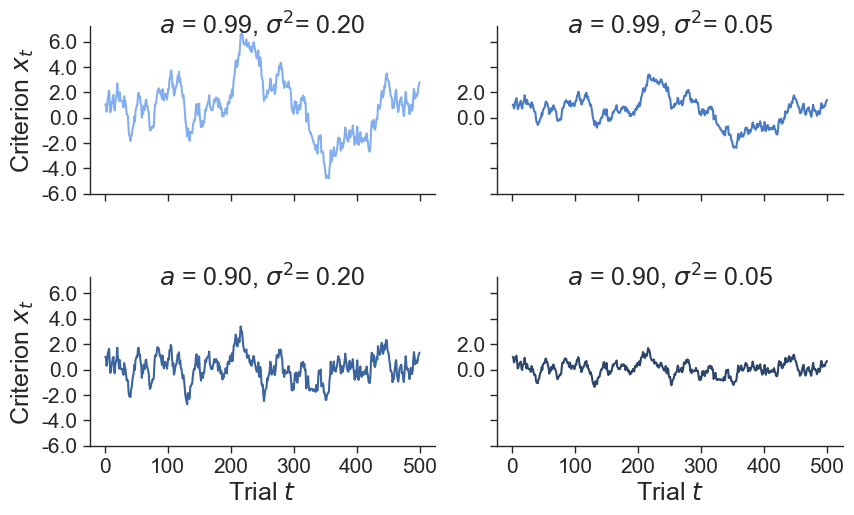

In [24]:
n_trials = 500

def generate_criterion_fluctuations(key, a, sigmasq):

    """
    Simulate criterion fluctuations as an AR(1) process
    """

    k1, k2 = jr.split(key, 2)

    x_i0 = tfd.Normal(0, 1.0).sample(seed=k1)
    def _step(x_it, key):
        x_itp1 = tfd.Normal(a * x_it, jnp.sqrt(sigmasq)).sample(seed=key)
        return x_itp1, x_it
    _, x_i = lax.scan(_step, x_i0, jr.split(k2, n_trials))

    return x_i


# Generate a dataset
key = jr.PRNGKey(0)

criterion_fluctuations_HH = generate_criterion_fluctuations(key, .99, .2)
criterion_fluctuations_HL = generate_criterion_fluctuations(key, .99, .05)
criterion_fluctuations_LH = generate_criterion_fluctuations(key, .90, .2)
criterion_fluctuations_LL = generate_criterion_fluctuations(key, .90, .05)

condition = np.repeat(["$a$ = 0.99, $\sigma^2$= 0.20", "$a$ = 0.99, $\sigma^2$= 0.05", "$a$ = 0.90, $\sigma^2$= 0.20", "$a$ = 0.90, $\sigma^2$= 0.05"], n_trials)
index = np.tile(np.arange(1, n_trials+1), 4) # repeat for number of conditions (4)
criterion_fluctuations = jnp.concatenate((criterion_fluctuations_HH, criterion_fluctuations_HL, criterion_fluctuations_LH, criterion_fluctuations_LL)) # make sure order is same as condition variable
df_model = pd.DataFrame({"index": index, "criterion_fluctuations": criterion_fluctuations, "condition": condition})


# Plot criterion trajectories
colors = ["#83aff0","#4779c4","#3c649f","#2c456b"]
plt.figure(figsize=(6, 6), dpi=600)
plot = sns.relplot(data=df_model, x="index", y="criterion_fluctuations", col="condition", col_wrap=2, kind="line", height=3, aspect=1.5)

for ax, color in zip(plot.axes.flatten(), colors):
    for line in ax.lines:
        line.set_color(color)

plot.set_axis_labels("Trial $t$", "Criterion $x_t$", size=18)
plot.set_titles(col_template="{col_name}", size=18, y=0.9)
plot.set(xticks=np.arange(0, 501, 100))
plot.set_xticklabels(np.arange(0, 501, 100), size=15)
plot.set(yticks=np.arange(-6, 6.01, 2))
plot.set_yticklabels(np.arange(-6, 6.01, 2), size=15)

#plt.savefig("illustration_ar_paramss.png", bbox_inches='tight', dpi=600)

Initialize global parameters before we start with correction of the three effects:
- underestimation d'
- underestimation psychometric slope
- apparent sequential effects

In [18]:
key = jr.PRNGKey(1)

num_inputs = 1 # slope
num_subjects = 50
num_trials = 5000

mu_w = 1.25 # slope
sigma_w = 0.1


# Define true model
# H is high, L is low, first letter is for a, second letter for sigmasq
# so true_model_HH has high values for a and high values for sigmasq
true_model_fixed = HierarchicalBernoulliLDS(num_inputs, 0.0, 1e-5, mu_w, sigma_w, 1e-5, 1e-5, 1e-5) # for fixed condition
true_model_HH = HierarchicalBernoulliLDS(num_inputs, 0.98, 0.005, mu_w, sigma_w, 0.20, 10.0, 1e-5) # for criterion fluctuations
true_model_HL = HierarchicalBernoulliLDS(num_inputs, 0.98, 0.005, mu_w, sigma_w, 0.10, 5.0, 1e-5) # for criterion fluctuations
true_model_LH = HierarchicalBernoulliLDS(num_inputs, 0.95, 0.005, mu_w, sigma_w, 0.20, 10.0, 1e-5) # for criterion fluctuations
true_model_LL = HierarchicalBernoulliLDS(num_inputs, 0.95, 0.005, mu_w, sigma_w, 0.10, 5.0, 1e-5) # for criterion fluctuations

### Criterion fluctuations and d'

In [19]:
# Simulate data (with only 1 evidence level)
inputs_dprime = tfd.Normal(0, 1).sample(sample_shape=(num_subjects, num_trials, num_inputs), seed=key)
inputs_dprime -= inputs_dprime.mean(axis=0) # mean-center the inputs


# Sample params, states, and emissions from true model
true_params_fixed_dprime, true_states_fixed_dprime, emissions_fixed_dprime = true_model_fixed.sample(key, inputs_dprime, criterion_fluctuations=False) # fixed criterion of 0, no fluctuations
true_params_HH_dprime, true_states_HH_dprime, emissions_HH_dprime = true_model_HH.sample(key, inputs_dprime, criterion_fluctuations=True)
true_params_HL_dprime, true_states_HL_dprime, emissions_HL_dprime = true_model_HL.sample(key, inputs_dprime, criterion_fluctuations=True)
true_params_LH_dprime, true_states_LH_dprime, emissions_LH_dprime = true_model_LH.sample(key, inputs_dprime, criterion_fluctuations=True)
true_params_LL_dprime, true_states_LL_dprime, emissions_LL_dprime = true_model_LL.sample(key, inputs_dprime, criterion_fluctuations=True)

#### Calculate d prime and criterion using standard SDT calculation

In [20]:
def dprime_fnc(resp, cresp, crit=False):

    """
    Function to estimate d'
    """

    n = resp.shape[0]

    hit = np.zeros(n)
    hit[(cresp == 1) & (resp == 1)] = 1

    fa = np.zeros(n)
    fa[(cresp == 0) & (resp == 1)] = 1

    phit = np.sum(hit) / np.sum(cresp)
    pfa = np.sum(fa) / np.sum(cresp == 0)

    phit = 0.01 if phit == 0 else 0.99 if phit == 1 else phit
    pfa = 0.01 if pfa == 0 else 0.99 if pfa == 1 else pfa

    if crit:
        return -0.5 * (norm.ppf(phit) + norm.ppf(pfa))
    else:
        return norm.ppf(phit) - norm.ppf(pfa)


def calculate_dprime_for_each_subject(inputs, emissions):

    """
    Calculate d prime and criterion for each subject in a dataset
    """

    all_d_prime = []
    all_c_prime = []

    for subj in range(num_subjects):
      cresp = np.where(inputs[subj,:,1] < 0, 0, 1) # check correct response by comparing evidence to 0
      resp = emissions[subj,:]

      all_d_prime.append(dprime_fnc(resp, cresp, crit=False))
      all_c_prime.append(dprime_fnc(resp, cresp, crit=True))

    return all_d_prime, all_c_prime


# Calculate d' and c'
# inputs are the same for all conditions
d_prime_fixed, c_prime_fixed = calculate_dprime_for_each_subject(inputs_dprime, emissions_fixed_dprime)
d_prime_LL, c_prime_LL = calculate_dprime_for_each_subject(inputs_dprime, emissions_LL_dprime)
d_prime_LH, c_prime_LH = calculate_dprime_for_each_subject(inputs_dprime, emissions_LH_dprime)
d_prime_HL, c_prime_HL = calculate_dprime_for_each_subject(inputs_dprime, emissions_HL_dprime)
d_prime_HH, c_prime_HH = calculate_dprime_for_each_subject(inputs_dprime, emissions_HH_dprime)


d_estimate = np.concatenate((d_prime_fixed, d_prime_LL, d_prime_LH, d_prime_HL, d_prime_HH))
c_estimate = np.concatenate((c_prime_fixed, c_prime_LL, c_prime_LH, c_prime_HL, c_prime_HH))
condition = np.repeat(["  $a$=0\n$\sigma^2$=0","  $a$=0.95\n$\sigma^2$=0.10", "  $a$=0.95\n$\sigma^2$=0.20", "  $a$=0.98\n$\sigma^2$=0.10", "  $a$=0.98\n$\sigma^2$=0.20"], num_subjects)

# Create a dataframe for plotting
df_dprime = pd.DataFrame({"d_estimate": d_estimate, "c_estimate": c_estimate, "condition": condition})


#### Plot d' over conditions

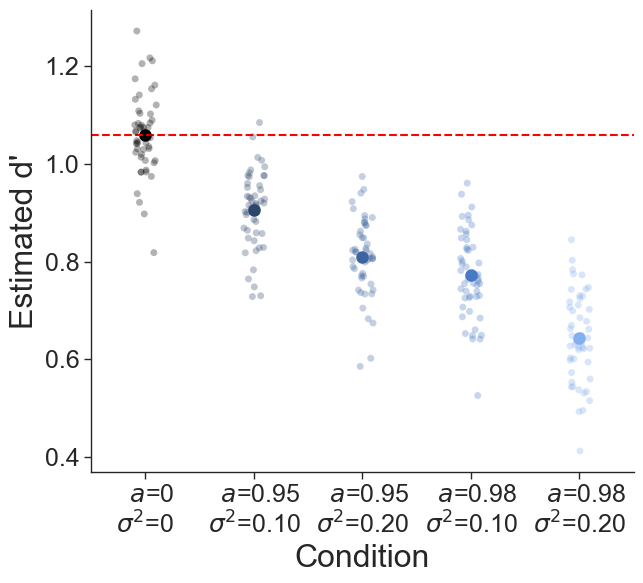

In [25]:
# Note that generative d prime is absent since we simulate data from the model and not SDT directly
colors = ["black","#2c456b","#3c649f", "#4779c4", "#83aff0"]

plt.figure(figsize=(7, 6))
sns.stripplot(
    data=df_dprime, x="condition",hue="condition", y="d_estimate",
    alpha=.3, palette=colors
)
sns.pointplot(
    data=df_dprime, x="condition",hue="condition", y="d_estimate",
    linestyle="none", errorbar=None,
    markersize=6, markeredgewidth=3,palette=colors
)

plt.axhline(y=1.06, color='red', linestyle='--')
plt.xlabel('Condition')
plt.ylabel("Estimated d'")
plt.legend('', frameon=False)

#plt.savefig("underestimation_dprimee.png", bbox_inches='tight', dpi=600)
plt.show()

#### Plot criterion over conditions

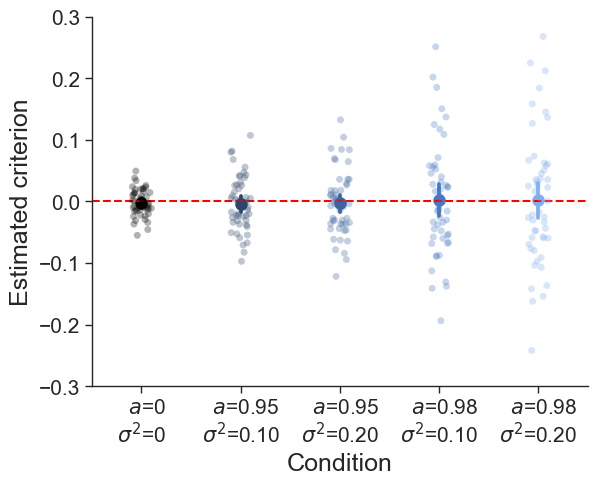

In [26]:
colors = ["black","#2c456b","#3c649f", "#4779c4", "#83aff0"]

sns.stripplot(
    data=df_dprime, x="condition",hue="condition", y="c_estimate",
    alpha=.3, palette=colors
)
sns.pointplot(
    data=df_dprime, x="condition",hue="condition", y="c_estimate",
    linestyle="none",
    markersize=6, markeredgewidth=3,palette=colors
)

plt.axhline(y=0, color='red', linestyle='--', label='y = 1')
plt.xlabel('Condition', size=18)
plt.ylabel("Estimated criterion", size=18)
plt.xticks(size=15)
plt.yticks(size=15)
plt.ylim(-.3,.3)
plt.legend('', frameon=False)

#plt.savefig("estimation_criterion.png", bbox_inches='tight', dpi=600)

### Criterion fluctuations and psychometric slope

C:\Users\u0141056\AppData\Local\Temp\ipykernel_25004\1576303801.py:82: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ax = df_psychometric.groupby(["evidence", "condition"])["mean_resp"].mean().unstack().plot(


<Figure size 4800x3600 with 0 Axes>

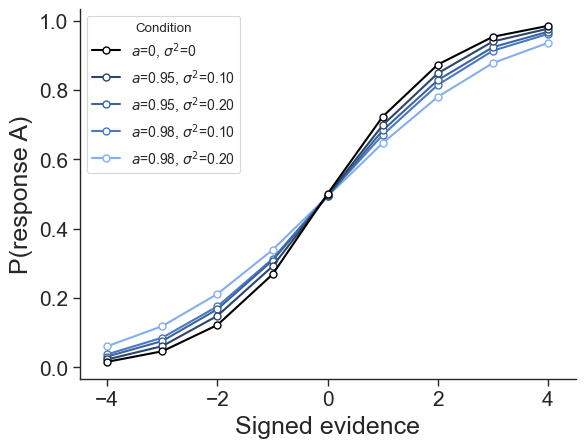

In [30]:
# Simulate data (with multiple evidence levels for psychometric slope)
k1, k2, k3, k4, k5, k6, k7, k8, k9 = jr.split(key, 9)

inputs0 = tfd.Normal(-4, 1).sample(sample_shape=(num_subjects, num_trials//9, num_inputs), seed=k1)
inputs1 = tfd.Normal(-3, 1).sample(sample_shape=(num_subjects, num_trials//9, num_inputs), seed=k2)
inputs2 = tfd.Normal(-2, 1).sample(sample_shape=(num_subjects, num_trials//9, num_inputs), seed=k3)
inputs3 = tfd.Normal(-1, 1).sample(sample_shape=(num_subjects, num_trials//9, num_inputs), seed=k4)
inputs4 = tfd.Normal(0, 1).sample(sample_shape=(num_subjects, num_trials//9, num_inputs), seed=k5)
inputs5 = tfd.Normal(1, 1).sample(sample_shape=(num_subjects, num_trials//9, num_inputs), seed=k6)
inputs6 = tfd.Normal(2, 1).sample(sample_shape=(num_subjects, num_trials//9, num_inputs), seed=k7)
inputs7 = tfd.Normal(3, 1).sample(sample_shape=(num_subjects, num_trials//9, num_inputs), seed=k8)
inputs8 = tfd.Normal(4, 1).sample(sample_shape=(num_subjects, num_trials//9, num_inputs), seed=k9)

# Create stimulus category variable
stimulus_category = jnp.tile(jnp.repeat(jnp.array([-4, -3, -2, -1, 0, 1, 2, 3, 4]), num_trials//9), num_subjects)

stimulus_category = stimulus_category.reshape([num_subjects,(num_trials//9)*9])

inputs = jnp.array(jnp.concatenate([inputs0, inputs1, inputs2, inputs3, inputs4, inputs5, inputs6, inputs7, inputs8], axis=1))

# Shuffle order (both are shuffled in the same way)
stimulus_category = jr.permutation(jr.PRNGKey(0), stimulus_category, axis=1)
inputs = jr.permutation(jr.PRNGKey(0), inputs, axis=1)


# Sample params, states, and emissions from true model
true_params_fixed, true_states_fixed, emissions_fixed = true_model_fixed.sample(key, inputs, criterion_fluctuations=False) # for fixed condition
true_params_HH, true_states_HH, emissions_HH = true_model_HH.sample(key, inputs, criterion_fluctuations=True)
true_params_HL, true_states_HL, emissions_HL = true_model_HL.sample(key, inputs, criterion_fluctuations=True)
true_params_LH, true_states_LH, emissions_LH = true_model_LH.sample(key, inputs, criterion_fluctuations=True)
true_params_LL, true_states_LL, emissions_LL = true_model_LL.sample(key, inputs, criterion_fluctuations=True)


def calculation_psychometric(emissions):
    """
    Calculate the mean response for each stimulus category within each subject.
    Then take the average over subjects to obtain the mean response for the
    psychometric function.
    """
    mean_resp_all_subj = []
    for subj in range(num_subjects):
        temp_df = pd.DataFrame({"resp" : emissions[subj],"stimulus_category": stimulus_category[subj], "evidence": inputs[:,:,1][subj]})

        mean_resp = temp_df.groupby("stimulus_category")["resp"].mean().reset_index()
        mean_resp_all_subj.append(mean_resp["resp"])

    mean_resp_over_subj = np.mean(mean_resp_all_subj, axis=0) # take average p(resp) over subjects for each evidence level

    return mean_resp_over_subj



# Create dataframe for plotting
mean_resp_fixed = calculation_psychometric(emissions_fixed)
mean_resp_LL = calculation_psychometric(emissions_LL)
mean_resp_LH = calculation_psychometric(emissions_LH)
mean_resp_HL = calculation_psychometric(emissions_HL)
mean_resp_HH = calculation_psychometric(emissions_HH)

mean_resp = np.concatenate((mean_resp_fixed, mean_resp_LL, mean_resp_LH, mean_resp_HL, mean_resp_HH))

evidence = np.tile([-4, -3, -2, -1, 0, 1, 2, 3, 4], 5)  # Repeat number of parameter combinations (5)
condition = np.repeat([
    "$a$=0, $\sigma^2$=0",
    "$a$=0.95, $\sigma^2$=0.10",
    "$a$=0.95, $\sigma^2$=0.20",
    "$a$=0.98, $\sigma^2$=0.10",
    "$a$=0.98, $\sigma^2$=0.20"], 9)  # Repeat for the number of evidence levels (9)

df_psychometric = pd.DataFrame({"evidence": evidence, "condition": condition, "mean_resp": mean_resp})
df_psychometric["condition"] = pd.Categorical(df_psychometric["condition"], categories=[
    "$a$=0.98, $\sigma^2$=0.20",
    "$a$=0.98, $\sigma^2$=0.10",
    "$a$=0.95, $\sigma^2$=0.20",
    "$a$=0.95, $\sigma^2$=0.10",
    "$a$=0, $\sigma^2$=0"])


# Plotting
colors = ["#83aff0","#4779c4","#3c649f","#2c456b","black"]
plt.figure(figsize=(8, 6), dpi=600)
ax = df_psychometric.groupby(["evidence", "condition"])["mean_resp"].mean().unstack().plot(
    style='o-', markerfacecolor='white', markersize=5, color=colors)

ax.set_xlim(-4.5, 4.5)
ax.set_xlabel("Signed evidence", size=18)
ax.set_ylabel("P(response A)", size=18)
ax.tick_params(axis='x', labelsize=15)
ax.tick_params(axis='y', labelsize=15)

# Reversing the order of legend labels
handles, labels = ax.get_legend_handles_labels()
ax.legend(reversed(handles), reversed(labels), title="Condition", loc="upper left", fontsize=10)
ax.grid(False)

#plt.savefig("underestimation_psychometric_slopee.png", bbox_inches='tight', dpi=600)
plt.show()

#### Plotting (zoomed in psychometric function)

C:\Users\u0141056\AppData\Local\Temp\ipykernel_25004\1940776443.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_psychometric.groupby(["evidence", "condition"])["mean_resp"]


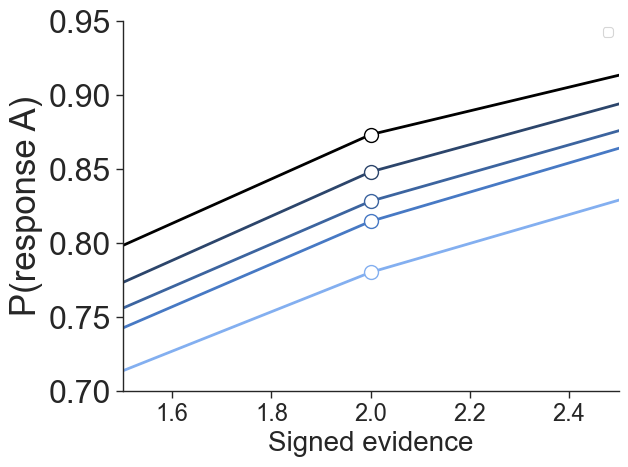

In [32]:
colors = ["#83aff0","#4779c4","#3c649f","#2c456b","black"]

p_psychometric = (
    df_psychometric.groupby(["evidence", "condition"])["mean_resp"]
    .mean()
    .unstack()
    .plot(style='o-', markerfacecolor='white', markersize=10, linewidth=2, color=colors)
)

p_psychometric.set_xlim(1.5, 2.5)
p_psychometric.set_ylim(.7, .95)

p_psychometric.set_xlabel("Signed evidence", size=20)
p_psychometric.set_ylabel("P(response A)", size=25)
p_psychometric.tick_params(axis='x', labelsize=17)
p_psychometric.tick_params(axis='y', labelsize=23)
p_psychometric.legend([]) # drop legend

p_psychometric.grid(False)

#plt.savefig("underestimation_psychometric_slope_zoomed_in.png", bbox_inches='tight', dpi=600)
plt.show()

### Criterion fluctuations and P(repeat response)

In [33]:
# Add previous response to input variable
def add_prev_resp(inputs, emissions):
    # Create previous response variable by shifting responses (emissions)
    # Add a 0 as the first element in each row (could be better but adding a 0 for everybody with 5000 trials won't matter much)
    prev_resp = jnp.insert(emissions, 0, 0, axis=1)

    # Delete the last element in each row
    prev_resp = jnp.delete(prev_resp, -1, axis=1)
    prev_resp = jnp.where(prev_resp == 0, -1, 1) # change 0 to -1

    # Add prev resp to inputs
    inputs_with_prevresp = jnp.concatenate((inputs, prev_resp[..., jnp.newaxis]), axis=2)

    return inputs_with_prevresp


inputs_fixed = add_prev_resp(inputs, emissions_fixed) # structure output: [slope evidence, previous response]
inputs_HH = add_prev_resp(inputs, emissions_HH)
inputs_HL = add_prev_resp(inputs, emissions_HL)
inputs_LH = add_prev_resp(inputs, emissions_LH)
inputs_LL = add_prev_resp(inputs, emissions_LL)

In [34]:
def calculate_p_repeat(inputs, emissions):
  # Check whether previous response == current response
  repeat_response = inputs[:,:,1] == jnp.where(emissions == 0, -1, 1)

  # Sum and divide by num_trials to get probability of repeating a response
  p_repeat_response = repeat_response.sum(axis=1)/num_trials

  # Calculate the average probability over subjects
  mean = jnp.mean(p_repeat_response)

  return p_repeat_response, mean


# Calculate P(repeat response) for every condition
p_rep_HH, mean_p_rep_HH = calculate_p_repeat(inputs_HH, emissions_HH)
p_rep_HL, mean_p_rep_HL = calculate_p_repeat(inputs_HL, emissions_HL)
p_rep_LH, mean_p_rep_LH = calculate_p_repeat(inputs_LH, emissions_LH)
p_rep_LL, mean_p_rep_LL = calculate_p_repeat(inputs_LL, emissions_LL)
p_rep_fixed, mean_p_rep_fixed = calculate_p_repeat(inputs_fixed, emissions_fixed)



# Create a dataframe for plotting
p_repeat = np.concatenate((p_rep_fixed, p_rep_LL, p_rep_LH, p_rep_HL, p_rep_HH))
condition = np.repeat([" $a$ = 0\n$\sigma^2$= 0"," $a$ = 0.95\n$\sigma^2$= 0.10", " $a$ = 0.95\n$\sigma^2$= 0.20", " $a$ = 0.98\n$\sigma^2$= 0.10", " $a$ = 0.98\n$\sigma^2$= 0.20"], num_subjects)

df_sequential = pd.DataFrame({"p_repeat": p_repeat, "condition": condition})


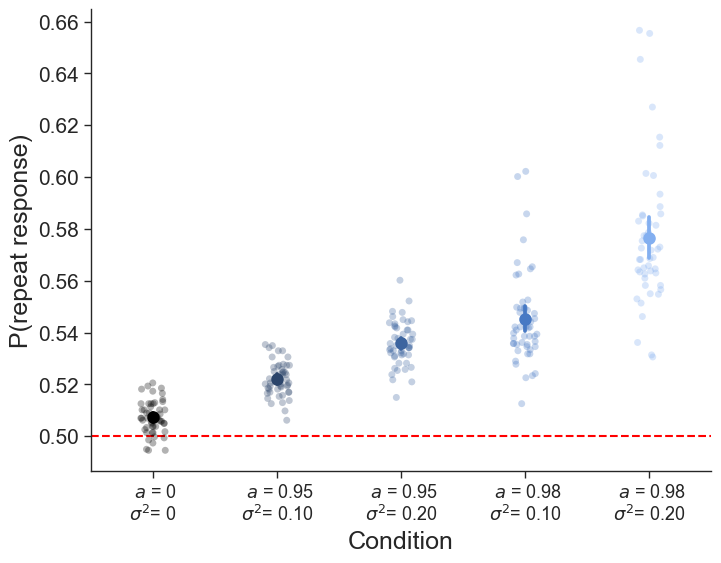

In [35]:
# Plotting
colors = ["black","#2c456b","#3c649f", "#4779c4", "#83aff0"]
plt.figure(figsize=(8, 6))
sns.stripplot(
    data=df_sequential, x="condition",hue="condition", y="p_repeat",
    alpha=.3, palette=colors
)
sns.pointplot(
    data=df_sequential, x="condition",hue="condition", y="p_repeat",
    linestyle="none",
    markersize=6, markeredgewidth=3,palette=colors
)


plt.axhline(y=.5, color='red', linestyle='--', label='y = 1')
plt.xlabel('Condition', fontsize=18)
plt.ylabel("P(repeat response)", fontsize=18)
plt.yticks(fontsize=15)
plt.xticks(fontsize=13)
plt.legend('', frameon=False)

#plt.savefig("repetition_effectss.png", bbox_inches='tight', dpi=600)

## Using hMFC to correct for apparent sequential effects and underestimation psychometric slope

### True model

In [108]:
num_inputs = 2 # slope, previous response
num_subjects = 25
num_trials = 2500

mu_w = jnp.array([1.25, 0.5]) # slope, previous response
sigma_w = jnp.array([0.1, 0.1])


# Define true model
# H is high, L is low, first letter is for a, second letter for sigmasq
# so true_model_HH has high values for a and high values for sigmasq
# True sigma_mu_x fixed to zero!
true_model_fixed = HierarchicalBernoulliLDS(num_inputs, 1e-4, 1e-4, mu_w, sigma_w, 1e-4, 1e-4, 1e-4) # for fixed condition (exact fluctuation params don't matter because fluctuations are just a flat line of zeros)
true_model_HH = HierarchicalBernoulliLDS(num_inputs, 0.98, 0.01, mu_w, sigma_w, 0.20, 10.0, 0.1) # for criterion fluctuations
true_model_HL = HierarchicalBernoulliLDS(num_inputs, 0.98, 0.01, mu_w, sigma_w, 0.10, 5.0, 0.1) # for criterion fluctuations
true_model_LH = HierarchicalBernoulliLDS(num_inputs, 0.95, 0.01, mu_w, sigma_w, 0.20, 10.0, 0.1) # for criterion fluctuations
true_model_LL = HierarchicalBernoulliLDS(num_inputs, 0.95, 0.01, mu_w, sigma_w, 0.10, 5.0, 0.1) # for criterion fluctuations


### Sample parameters, inputs, and response from true model

In [17]:
# Sample params, states, and emissions from true model

key = jr.PRNGKey(0)

true_params_fixed, true_states_fixed, emissions_fixed, inputs_fixed = true_model_fixed.sample_with_previous_response(key, criterion_fluctuations=True) # fixed criterion of 0, no fluctuations
# true_params_HH, true_states_HH, emissions_HH, inputs_HH = true_model_HH.sample_with_previous_response(key, criterion_fluctuations=True)
# true_params_HL, true_states_HL, emissions_HL, inputs_HL = true_model_HL.sample_with_previous_response(key, criterion_fluctuations=True)
# true_params_LH, true_states_LH, emissions_LH, inputs_LH = true_model_LH.sample_with_previous_response(key, criterion_fluctuations=True)
# true_params_LL, true_states_LL, emissions_LL, inputs_LL = true_model_LL.sample_with_previous_response(key, criterion_fluctuations=True)

In [18]:
true_params_fixed

{'a': Array([3.14135978e-05, 2.77780055e-05, 1.79273920e-04, 2.14055501e-04,
        1.44396327e-04, 3.79733188e-04, 9.35637217e-05, 4.72890679e-06,
        5.70286829e-05, 1.99391725e-05, 1.20898570e-04, 2.09525097e-05,
        6.99899101e-06, 1.96274108e-04, 1.46020306e-04, 1.38238713e-04,
        1.86043006e-04, 1.14938026e-04, 2.48601049e-04, 1.84093296e-05,
        1.30065280e-04, 8.41756701e-05, 1.67098886e-04, 1.58257404e-04,
        1.20772544e-04], dtype=float32),
 'mu_x': Array([ 3.39911203e-05,  1.66087615e-04,  1.54000063e-05,  4.30819746e-05,
         2.84232829e-05,  5.93911936e-05,  1.08344655e-04, -2.40894187e-05,
         1.17777789e-04,  1.50347129e-04, -4.16980656e-05, -9.34035688e-06,
         9.53441668e-06,  2.17322395e-05, -4.81044117e-06,  9.15094497e-05,
         7.39771804e-06,  5.29118665e-07,  1.79977869e-04,  3.34420110e-05,
        -6.95337731e-05, -1.20940756e-04,  1.41355180e-04, -2.23694497e-05,
         5.80328779e-05], dtype=float32),
 'sigmasq': Arra

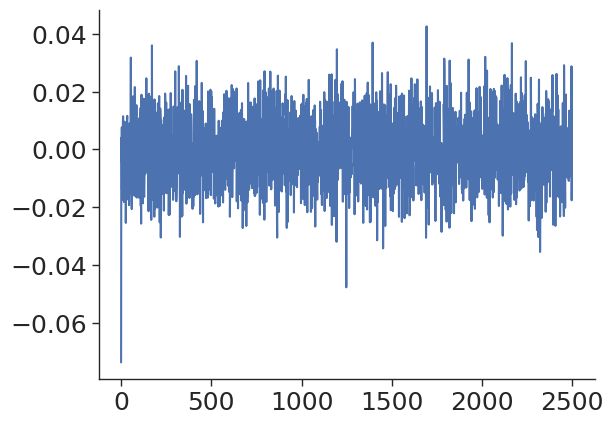

In [24]:
plt.plot(true_states_fixed[4,:])

In [12]:
def calculate_p_repeat(inputs, emissions):
  # Check whether previous response == current response
  repeat_response = inputs[:,:,1] == jnp.where(emissions == 0, -1, 1)

  # Sum and divide by num_trials to get probability of repeating a response
  p_repeat_response = repeat_response.sum(axis=1)/num_trials

  # Calculate the average probability over subjects
  mean = jnp.mean(p_repeat_response)

  return p_repeat_response, mean


# Calculate P(repeat response) for every condition
p_rep_HH, mean_p_rep_HH = calculate_p_repeat(inputs_HH, emissions_HH)
p_rep_HL, mean_p_rep_HL = calculate_p_repeat(inputs_HL, emissions_HL)
p_rep_LH, mean_p_rep_LH = calculate_p_repeat(inputs_LH, emissions_LH)
p_rep_LL, mean_p_rep_LL = calculate_p_repeat(inputs_LL, emissions_LL)
p_rep_fixed, mean_p_rep_fixed = calculate_p_repeat(inputs_fixed, emissions_fixed)



# Create a dataframe for plotting
p_repeat = np.concatenate((p_rep_fixed, p_rep_LL, p_rep_LH, p_rep_HL, p_rep_HH))
condition = np.repeat([" $a$ = 0\n$\sigma^2$= 0"," $a$ = 0.95\n$\sigma^2$= 0.10", " $a$ = 0.95\n$\sigma^2$= 0.20", " $a$ = 0.98\n$\sigma^2$= 0.10", " $a$ = 0.98\n$\sigma^2$= 0.20"], num_subjects)

df_sequential = pd.DataFrame({"p_repeat": p_repeat, "condition": condition})


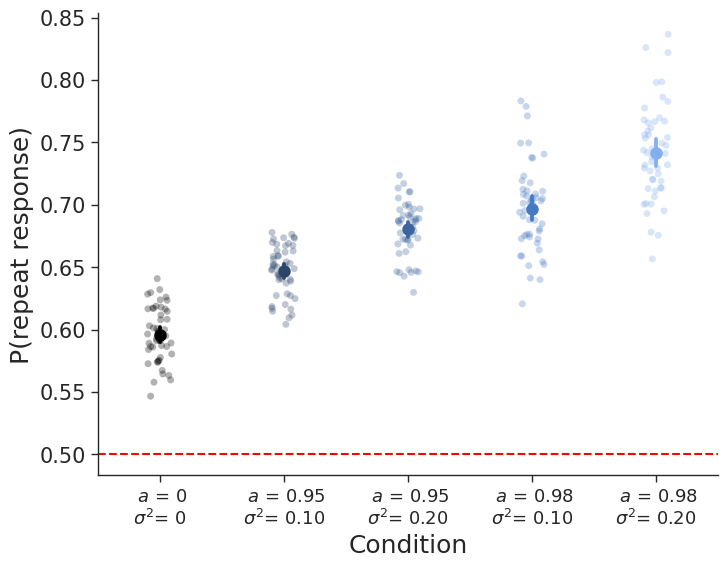

In [14]:
# Plotting
colors = ["black","#2c456b","#3c649f", "#4779c4", "#83aff0"]
plt.figure(figsize=(8, 6))
sns.stripplot(
    data=df_sequential, x="condition",hue="condition", y="p_repeat",
    alpha=.3, palette=colors
)
sns.pointplot(
    data=df_sequential, x="condition",hue="condition", y="p_repeat",
    linestyle="none",
    markersize=6, markeredgewidth=3,palette=colors
)


plt.axhline(y=.5, color='red', linestyle='--', label='y = 1')
plt.xlabel('Condition', fontsize=18)
plt.ylabel("P(repeat response)", fontsize=18)
plt.yticks(fontsize=15)
plt.xticks(fontsize=13)
plt.legend('', frameon=False)

plt.savefig("repetition_effects.png", bbox_inches='tight', dpi=600)

## Fit model

In [109]:
# criterion_fluctuations_estimated = True: criterion fluctuations are estimated -> hyperparams for a and sigmasq are estimated and initialized
# criterion_fluctuations_estimated = False: criterion fluctuations are NOT estimated -> hyperparams for a and sigmasq are not estimated and set to close to zero

# Create mask variable
masks = jnp.ones_like(emissions_fixed) # is same for all conditions
num_trials = emissions_fixed.shape[1]

def fit_model(inputs, emissions, key, criterion_fluctuations_estimated):

    # Initial values for hyperparameters
    init_nu_w = jnp.repeat(0.1, num_inputs)
    init_w = jnp.ones(num_inputs)

    # If no criterion fluctuations are estimated
    model = HierarchicalBernoulliLDS(num_inputs, 1e-4, 1e-4, init_w, init_nu_w, 1e-4, 1e-4, 1e-4)
    # If criterion fluctuations are estimated
    if criterion_fluctuations_estimated:
      model = HierarchicalBernoulliLDS(num_inputs, 0.90, 0.1, init_w, init_nu_w, 1e-4, 1e-4, 1e-4) 
    
    params, states, _, _ = model.sample_with_previous_response(key, criterion_fluctuations=True)

  
    # Fit model
    lps = jnp.zeros((num_iters,)) # log probability
    
    posterior_samples_mu_a = jnp.zeros((num_iters,))
    posterior_samples_sigma_a = jnp.zeros((num_iters,))
    posterior_samples_mu_w = jnp.zeros((num_iters, num_inputs))
    posterior_samples_sigma_w = jnp.zeros((num_iters, num_inputs))
    posterior_samples_mu_sigmasq = jnp.zeros((num_iters,))
    posterior_samples_beta_sigmasq = jnp.zeros((num_iters,))
    posterior_samples_sigma_mu_x = jnp.zeros((num_iters,))
    
    posterior_samples_a = jnp.zeros((num_iters, num_subjects))
    posterior_samples_sigmasq = jnp.zeros((num_iters, num_subjects))
    posterior_samples_w = jnp.zeros((num_iters, num_subjects, num_inputs))
    posterior_samples_mu_x = jnp.zeros((num_iters, num_subjects))
    

    for itr in progress_bar(range(num_iters)):
        this_key, key = jr.split(key)

        if criterion_fluctuations_estimated:
          lp, states, params, model = gibbs_step_with_criterion_fluctuations_estimation(this_key, emissions, masks, states, inputs, params, model)
        else:
          lp, states, params, model = gibbs_step_without_criterion_fluctuations_estimation(this_key, emissions, masks, states, inputs, params, model)

        lps = lps.at[itr].set(lp)
    
        posterior_samples_mu_a = posterior_samples_mu_a.at[itr].set(sigmoid(model.logit_mu_a))
        posterior_samples_sigma_a = posterior_samples_sigma_a.at[itr].set(jnp.exp(model.log_sigma_a))
        posterior_samples_mu_w = posterior_samples_mu_w.at[itr].set(model.mu_w)
        posterior_samples_sigma_w = posterior_samples_sigma_w.at[itr].set(jnp.exp(model.log_sigma_w))
        posterior_samples_mu_sigmasq = posterior_samples_mu_sigmasq.at[itr].set(jnp.exp(model.log_mu_sigmasq))
        posterior_samples_beta_sigmasq = posterior_samples_beta_sigmasq.at[itr].set(jnp.exp(model.log_beta_sigmasq))
        posterior_samples_sigma_mu_x = posterior_samples_sigma_mu_x.at[itr].set(jnp.exp(model.log_sigma_mu_x))
    
        posterior_samples_a = posterior_samples_a.at[itr].set(params['a'])
        posterior_samples_sigmasq = posterior_samples_sigmasq.at[itr].set(params['sigmasq'])
        posterior_samples_w = posterior_samples_w.at[itr].set(params['w'])
        posterior_samples_mu_x = posterior_samples_mu_x.at[itr].set(params['mu_x'])
    
        if itr == burn_in:
            states_sum = states
            states_sum_squared = states**2
        elif itr > burn_in:
            states_sum += states
            states_sum_squared += states**2

    mean_states = states_sum / (num_iters - burn_in)  # take average states over all iterations without burn_in
    sd_states = jnp.sqrt(states_sum_squared/(num_iters - burn_in)-mean_states**2) # chiastic formula for standard deviation
    

    return emissions, inputs, lps, posterior_samples_mu_a, posterior_samples_sigma_a, posterior_samples_mu_w, posterior_samples_sigma_w, posterior_samples_mu_sigmasq, posterior_samples_beta_sigmasq, posterior_samples_sigma_mu_x, posterior_samples_a, posterior_samples_sigmasq, posterior_samples_w, posterior_samples_mu_x, mean_states, sd_states  


In [61]:
jnp.mean(posterior_samples_a_fixed, axis=0)

Array([0.40086702, 0.4156372 , 0.36248666, 0.39312378, 0.3962714 ,
       0.31667536, 0.39431018, 0.35769862, 0.38842428, 0.42686972,
       0.38420373, 0.36124295, 0.36750448, 0.3681519 , 0.3283471 ,
       0.36817858, 0.33344632, 0.32276884, 0.3468121 , 0.38314608,
       0.33472252, 0.37146017, 0.37988296, 0.32706916, 0.36569256,
       0.33959216, 0.3467029 , 0.37936726, 0.36831263, 0.33671615,
       0.34403154, 0.39630696, 0.4129335 , 0.36318195, 0.34709752,
       0.32932287, 0.44120657, 0.33081424, 0.3733061 , 0.29086074,
       0.33164823, 0.383063  , 0.36006325, 0.33807933, 0.34627125,
       0.36306864, 0.39363742, 0.39217532, 0.3445529 , 0.3919854 ],      dtype=float32)

In [52]:
jnp.mean(posterior_samples_sigmasq_fixed, axis=0)

Array([0.12282882, 0.20858237, 0.49573913, 0.08800663, 0.09997752,
       0.10232589, 0.31512013, 0.07488965, 0.08596155, 0.1234315 ,
       0.1015262 , 0.07350006, 0.30401623, 0.33513075, 0.2449683 ,
       0.18725431, 0.0533495 , 0.40327263, 0.06459406, 0.08220938,
       0.13540873, 0.25255543, 0.21286757, 0.05934772, 0.40491205],      dtype=float32)

In [63]:
jnp.mean(posterior_samples_mu_w_fixed[1500:,:], axis=0)

Array([1.300439  , 0.50896835], dtype=float32)

(array([ 20.,  65., 156., 310., 367., 283., 140.,  49.,   5.,   5.]),
 array([1.17787755, 1.19183373, 1.2057898 , 1.21974587, 1.23370206,
        1.24765825, 1.26161432, 1.27557039, 1.28952658, 1.30348277,
        1.31743884]),
 <BarContainer object of 10 artists>)

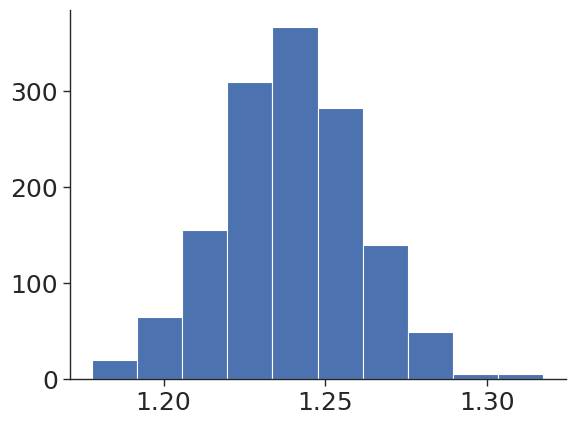

In [123]:
plt.hist(posterior_samples_mu_w_fixed[100:,0])

In [47]:
jnp.mean(posterior_samples_sigmasq_fixed, axis=0)

Array([0.12282882, 0.20858237, 0.49573913, 0.08800663, 0.09997752,
       0.10232589, 0.31512013, 0.07488965, 0.08596155, 0.1234315 ,
       0.1015262 , 0.07350006, 0.30401623, 0.33513075, 0.2449683 ,
       0.18725431, 0.0533495 , 0.40327263, 0.06459406, 0.08220938,
       0.13540873, 0.25255543, 0.21286757, 0.05934772, 0.40491205],      dtype=float32)

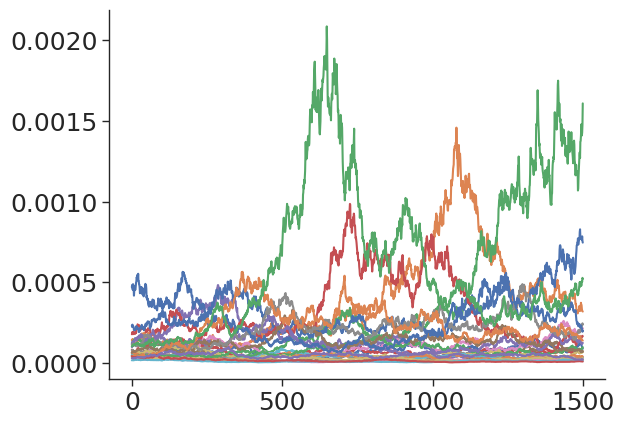

In [122]:
plt.plot(posterior_samples_sigmasq_fixed)
plt.show()

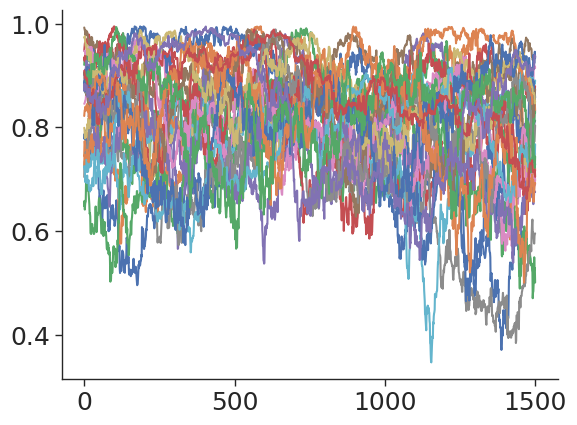

In [121]:
plt.plot(posterior_samples_a_fixed)
plt.show()

Text(0.05, 0.85, 'r = 0.70')

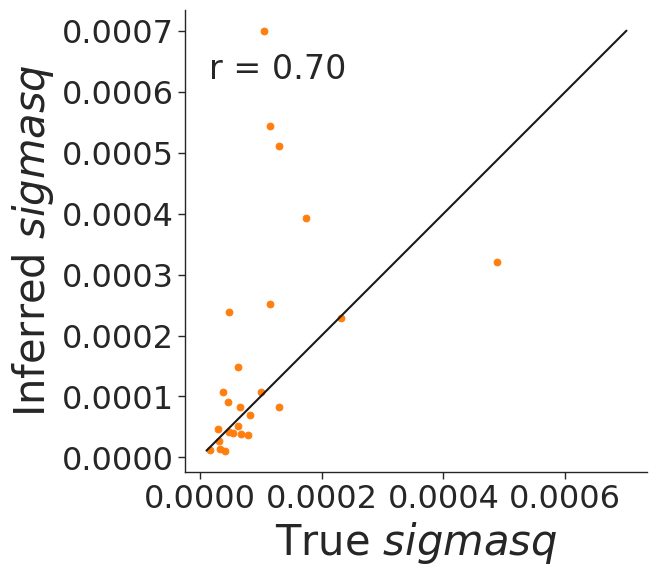

In [120]:
burn_in = 500
dataset = 0

sigmasq_min = min(true_params_fixed['sigmasq'].min(), jnp.mean(posterior_samples_sigmasq_fixed[burn_in:], axis=0).min())
sigmasq_max = max(true_params_fixed['sigmasq'].max(), jnp.mean(posterior_samples_sigmasq_fixed[burn_in:], axis=0).max())

plt.figure(figsize=(8, 6))
plt.scatter(true_params_fixed['sigmasq'], jnp.mean(posterior_samples_sigmasq_fixed[burn_in:], axis=0), color="#FF7F0E")
plt.plot([sigmasq_min, sigmasq_max], [sigmasq_min, sigmasq_max], '-k')
plt.xticks(size=23)
plt.yticks(size=23)
plt.xlabel("True $sigmasq$", size=30)
plt.ylabel("Inferred $sigmasq$",size=30)
#plt.title(r"Dataset {:d}".format(dataset))
plt.gca().set_aspect(1.0)
r, p = spearmanr(true_params_fixed['sigmasq'], jnp.mean(posterior_samples_sigmasq_fixed[burn_in:], axis=0))
plt.annotate('r = {:.2f}'.format(r), xy=(0.05, 0.85), xycoords='axes fraction')

Text(0.05, 0.85, 'r = 0.13')

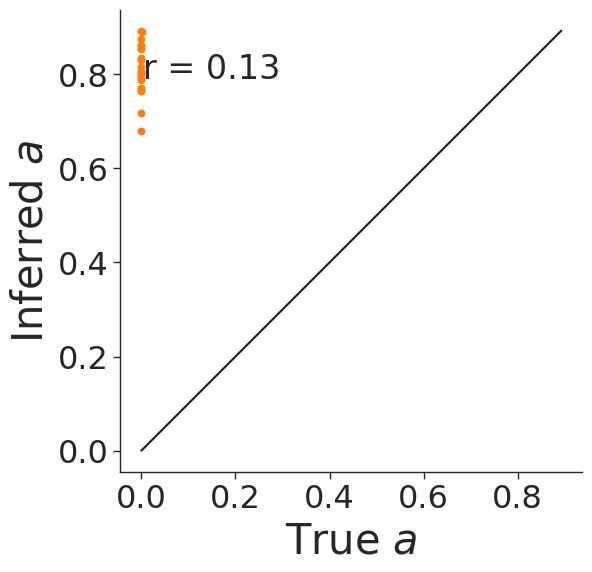

In [119]:
dataset = 0

a_min = min(true_params_fixed['a'].min(), jnp.mean(posterior_samples_a_fixed[burn_in:], axis=0).min())
a_max = max(true_params_fixed['a'].max(), jnp.mean(posterior_samples_a_fixed[burn_in:], axis=0).max())

plt.figure(figsize=(8, 6))
plt.scatter(true_params_fixed['a'], jnp.mean(posterior_samples_a_fixed[burn_in:], axis=0), color="#FF7F0E")
plt.plot([a_min, a_max], [a_min, a_max], '-k')
plt.xticks(size=23)
plt.yticks(size=23)
plt.xlabel("True $a$", size=30)
plt.ylabel("Inferred $a$",size=30)
#plt.title(r"Dataset {:d}".format(dataset))
plt.gca().set_aspect(1.0)
r, p = spearmanr(true_params_fixed['a'], jnp.mean(posterior_samples_a_fixed[burn_in:], axis=0))
plt.annotate('r = {:.2f}'.format(r), xy=(0.05, 0.85), xycoords='axes fraction')

Text(0.05, 0.85, 'r = 0.33')

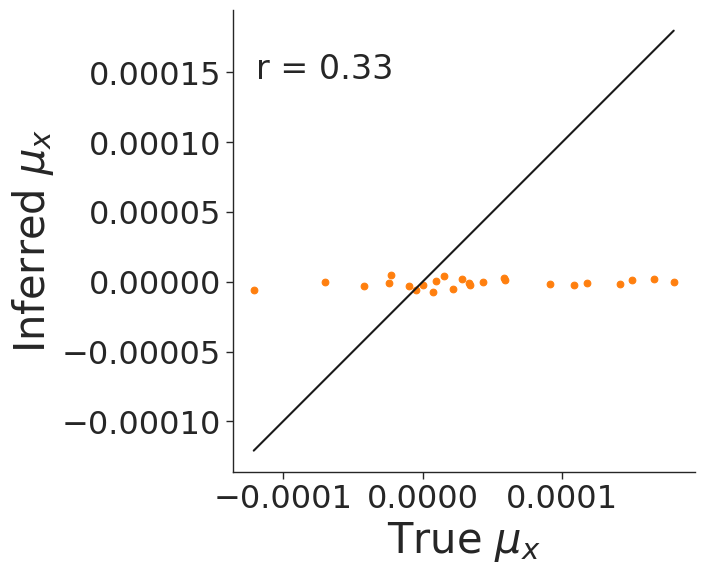

In [118]:
dataset = 0

mu_x_min = min(true_params_fixed['mu_x'].min(), jnp.mean(posterior_samples_mu_x_fixed[burn_in:], axis=0).min())
mu_x_max = max(true_params_fixed['mu_x'].max(), jnp.mean(posterior_samples_mu_x_fixed[burn_in:], axis=0).max())

plt.figure(figsize=(8, 6))
plt.scatter(true_params_fixed['mu_x'], jnp.mean(posterior_samples_mu_x_fixed[burn_in:], axis=0), color="#FF7F0E")
plt.plot([mu_x_min, mu_x_max], [mu_x_min, mu_x_max], '-k')
plt.xticks(size=23)
plt.yticks(size=23)
plt.xlabel("True $\mu_x$", size=30)
plt.ylabel("Inferred $\mu_x$",size=30)
#plt.title(r"Dataset {:d}".format(dataset))
plt.gca().set_aspect(1.0)
r, p = spearmanr(true_params_fixed['mu_x'], jnp.mean(posterior_samples_mu_x_fixed[burn_in:], axis=0))
plt.annotate('r = {:.2f}'.format(r), xy=(0.05, 0.85), xycoords='axes fraction')

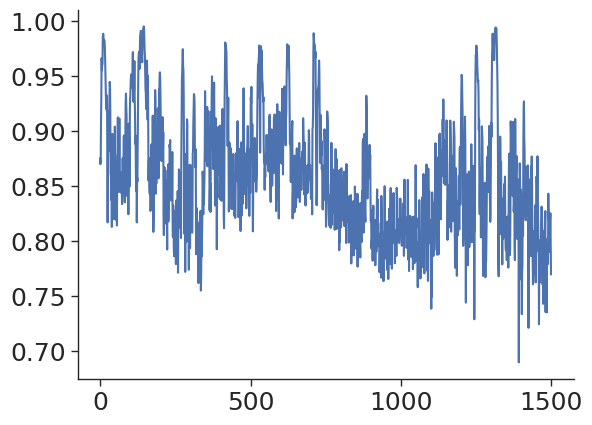

In [117]:
plt.plot(posterior_samples_mu_a_fixed)

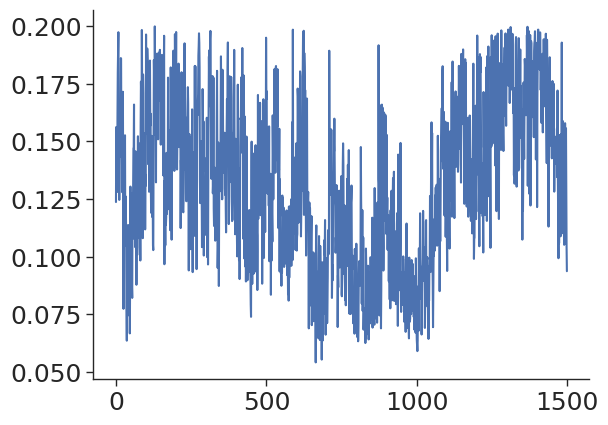

In [116]:
plt.plot(posterior_samples_sigma_a_fixed)

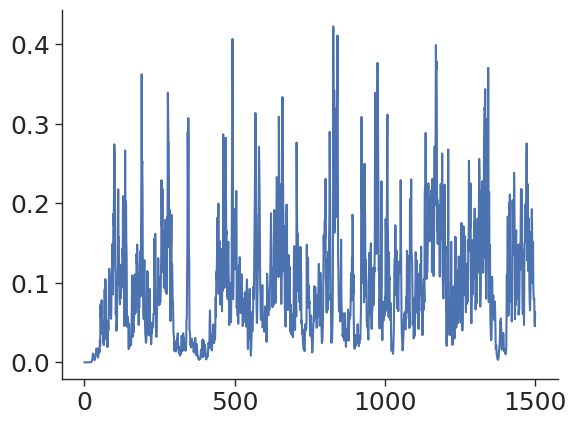

In [115]:
plt.plot(posterior_samples_mu_sigmasq_fixed)

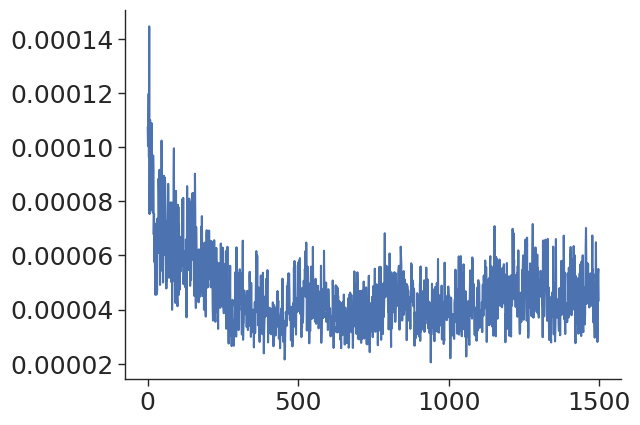

In [114]:
plt.plot(posterior_samples_beta_sigmasq_fixed)

In [71]:
.5/.1 + 1

6.0

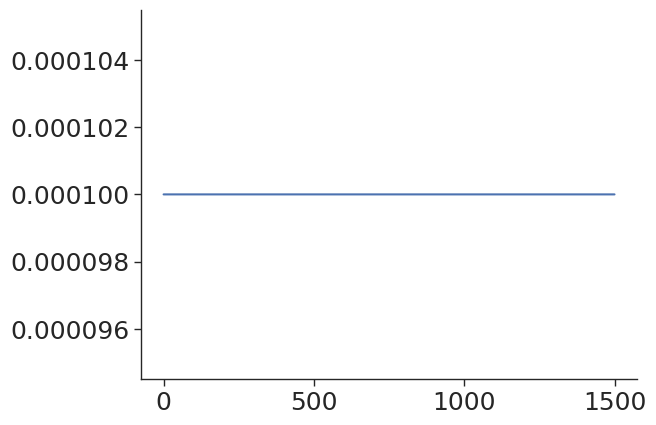

In [113]:
plt.plot(posterior_samples_sigma_mu_x_fixed)

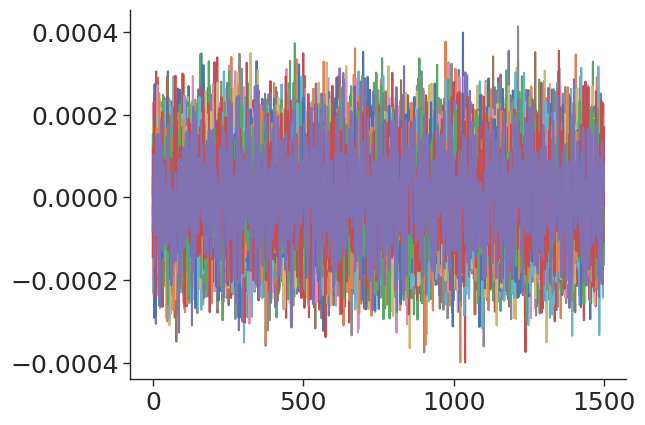

In [112]:
plt.plot(posterior_samples_mu_x_fixed)
plt.show()

In [110]:
burn_in = 500
num_iters = 1500

key = jr.PRNGKey(0)

emissions_fixed, inputs_fixed, lps_fixed, posterior_samples_mu_a_fixed, posterior_samples_sigma_a_fixed, posterior_samples_mu_w_fixed, posterior_samples_sigma_w_fixed, posterior_samples_mu_sigmasq_fixed, posterior_samples_beta_sigmasq_fixed, posterior_samples_sigma_mu_x_fixed, posterior_samples_a_fixed, posterior_samples_sigmasq_fixed, posterior_samples_w_fixed, posterior_samples_mu_x_fixed, mean_states_fixed, sd_states_fixed = fit_model(inputs_fixed, emissions_fixed, key, criterion_fluctuations_estimated=True)
# emissions_LL, inputs_LL, lps_LL, posterior_samples_mu_a_LL, posterior_samples_sigma_a_LL, posterior_samples_mu_w_LL, posterior_samples_sigma_w_LL, posterior_samples_mu_sigmasq_LL, posterior_samples_beta_sigmasq_LL, posterior_samples_sigma_mu_x_LL, posterior_samples_a_LL, posterior_samples_sigmasq_LL, posterior_samples_w_LL, posterior_samples_mu_x_LL, mean_states_LL, sd_states_LL = fit_model(inputs_LL, emissions_LL, key, criterion_fluctuations_estimated=True)
# emissions_LH, inputs_LH, lps_LH, posterior_samples_mu_a_LH, posterior_samples_sigma_a_LH, posterior_samples_mu_w_LH, posterior_samples_sigma_w_LH, posterior_samples_mu_sigmasq_LH, posterior_samples_beta_sigmasq_LH, posterior_samples_sigma_mu_x_LH, posterior_samples_a_LH, posterior_samples_sigmasq_LH, posterior_samples_w_LH, posterior_samples_mu_x_LH, mean_states_LH, sd_states_LH = fit_model(inputs_LH, emissions_LH, key, criterion_fluctuations_estimated=True)
# emissions_HL, inputs_HL, lps_HL, posterior_samples_mu_a_HL, posterior_samples_sigma_a_HL, posterior_samples_mu_w_HL, posterior_samples_sigma_w_HL, posterior_samples_mu_sigmasq_HL, posterior_samples_beta_sigmasq_HL, posterior_samples_sigma_mu_x_HL, posterior_samples_a_HL, posterior_samples_sigmasq_HL, posterior_samples_w_HL, posterior_samples_mu_x_HL, mean_states_HL, sd_states_HL = fit_model(inputs_HL, emissions_HL, key, criterion_fluctuations_estimated=True)
# emissions_HH, inputs_HH, lps_HH, posterior_samples_mu_a_HH, posterior_samples_sigma_a_HH, posterior_samples_mu_w_HH, posterior_samples_sigma_w_HH, posterior_samples_mu_sigmasq_HH, posterior_samples_beta_sigmasq_HH, posterior_samples_sigma_mu_x_HH, posterior_samples_a_HH, posterior_samples_sigmasq_HH, posterior_samples_w_HH, posterior_samples_mu_x_HH, mean_states_HH, sd_states_HH = fit_model(inputs_HH, emissions_HH, key, criterion_fluctuations_estimated=True)

# emissions_fixed_no_est_CF, inputs_fixed_no_est_CF, lps_fixed_no_est_CF, posterior_samples_mu_a_fixed_no_est_CF, posterior_samples_sigma_a_fixed_no_est_CF, posterior_samples_mu_w_fixed_no_est_CF, posterior_samples_sigma_w_fixed_no_est_CF, posterior_samples_mu_sigmasq_fixed_no_est_CF, posterior_samples_beta_sigmasq_fixed_no_est_CF, posterior_samples_sigma_mu_x_fixed_no_est_CF, posterior_samples_a_fixed_no_est_CF, posterior_samples_sigmasq_fixed_no_est_CF, posterior_samples_w_fixed_no_est_CF, posterior_samples_mu_x_fixed_no_est_CF, mean_states_fixed_no_est_CF, sd_states_fixed_no_est_CF = fit_model(inputs_fixed, emissions_fixed, key, criterion_fluctuations_estimated=False)
# emissions_LL_no_est_CF, inputs_LL_no_est_CF, lps_LL_no_est_CF, posterior_samples_mu_a_LL_no_est_CF, posterior_samples_sigma_a_LL_no_est_CF, posterior_samples_mu_w_LL_no_est_CF, posterior_samples_sigma_w_LL_no_est_CF, posterior_samples_mu_sigmasq_LL_no_est_CF, posterior_samples_beta_sigmasq_LL_no_est_CF, posterior_samples_sigma_mu_x_LL_no_est_CF, posterior_samples_a_LL_no_est_CF, posterior_samples_sigmasq_LL_no_est_CF, posterior_samples_w_LL_no_est_CF, posterior_samples_mu_x_LL_no_est_CF, mean_states_LL_no_est_CF, sd_states_LL_no_est_CF = fit_model(inputs_LL, emissions_LL, key, criterion_fluctuations_estimated=False)
# emissions_LH_no_est_CF, inputs_LH_no_est_CF, lps_LH_no_est_CF, posterior_samples_mu_a_LH_no_est_CF, posterior_samples_sigma_a_LH_no_est_CF, posterior_samples_mu_w_LH_no_est_CF, posterior_samples_sigma_w_LH_no_est_CF, posterior_samples_mu_sigmasq_LH_no_est_CF, posterior_samples_beta_sigmasq_LH_no_est_CF, posterior_samples_sigma_mu_x_LH_no_est_CF, posterior_samples_a_LH_no_est_CF, posterior_samples_sigmasq_LH_no_est_CF, posterior_samples_w_LH_no_est_CF, posterior_samples_mu_x_LH_no_est_CF, mean_states_LH_no_est_CF, sd_states_LH_no_est_CF = fit_model(inputs_LH, emissions_LH, key, criterion_fluctuations_estimated=False)
# emissions_HL_no_est_CF, inputs_HL_no_est_CF, lps_HL_no_est_CF, posterior_samples_mu_a_HL_no_est_CF, posterior_samples_sigma_a_HL_no_est_CF, posterior_samples_mu_w_HL_no_est_CF, posterior_samples_sigma_w_HL_no_est_CF, posterior_samples_mu_sigmasq_HL_no_est_CF, posterior_samples_beta_sigmasq_HL_no_est_CF, posterior_samples_sigma_mu_x_HL_no_est_CF, posterior_samples_a_HL_no_est_CF, posterior_samples_sigmasq_HL_no_est_CF, posterior_samples_w_HL_no_est_CF, posterior_samples_mu_x_HL_no_est_CF, mean_states_HL_no_est_CF, sd_states_HL_no_est_CF = fit_model(inputs_HL, emissions_HL, key, criterion_fluctuations_estimated=False)
# emissions_HH_no_est_CF, inputs_HH_no_est_CF, lps_HH_no_est_CF, posterior_samples_mu_a_HH_no_est_CF, posterior_samples_sigma_a_HH_no_est_CF, posterior_samples_mu_w_HH_no_est_CF, posterior_samples_sigma_w_HH_no_est_CF, posterior_samples_mu_sigmasq_HH_no_est_CF, posterior_samples_beta_sigmasq_HH_no_est_CF, posterior_samples_sigma_mu_x_HH_no_est_CF, posterior_samples_a_HH_no_est_CF, posterior_samples_sigmasq_HH_no_est_CF, posterior_samples_w_HH_no_est_CF, posterior_samples_mu_x_HH_no_est_CF, mean_states_HH_no_est_CF, sd_states_HH_no_est_CF = fit_model(inputs_HH, emissions_HH, key, criterion_fluctuations_estimated=False)


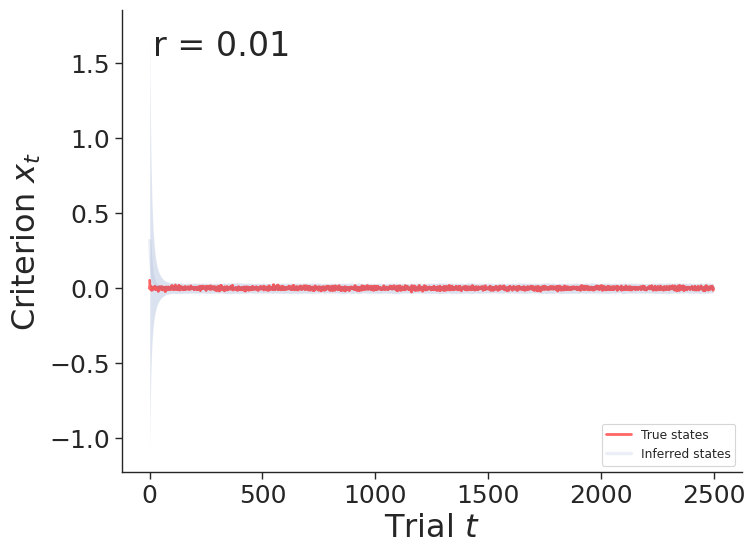

In [111]:
subject = 5

posterior_states_mean = mean_states_fixed[subject,:]
posterior_states_sd = sd_states_fixed[subject,:]

plt.figure(figsize=(8, 6))
plt.plot(true_states_fixed[subject], label="True states", linewidth=2, color='red', alpha=.6)
plt.plot(posterior_states_mean, label="Inferred states", linewidth=2.5, alpha=.1)
plt.fill_between(jnp.arange(num_trials),
          posterior_states_mean - 2 * posterior_states_sd,
          posterior_states_mean + 2 * posterior_states_sd, alpha=0.2)
plt.xlabel("Trial $t$")
plt.ylabel("Criterion $x_t$")
plt.legend(loc='lower right')
r, p = spearmanr(true_states_fixed[subject], posterior_states_mean)
plt.annotate('r = {:.2f}'.format(r), xy=(0.05, 0.90), xycoords='axes fraction')
sns.despine()
plt.show()

In [35]:
true_states_HH[0].shape

(5000,)

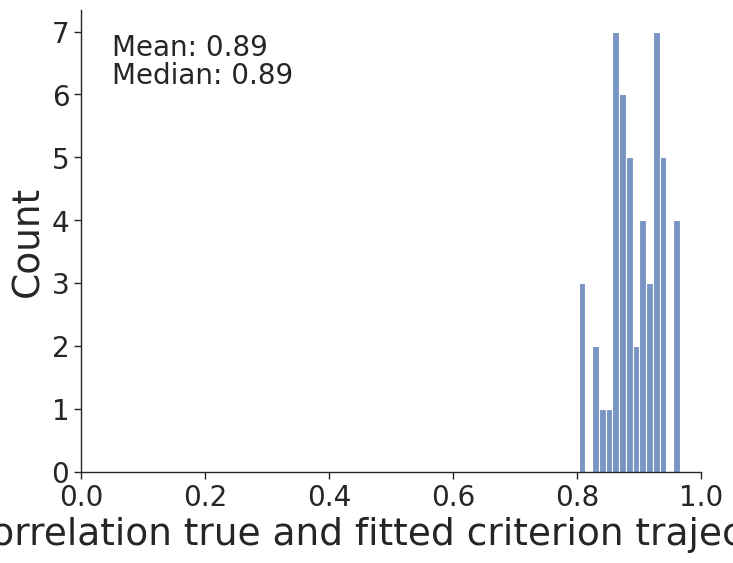

In [18]:
correlations_inferred_and_fitted_states = []

for subject in range(num_subjects):
    r, _= spearmanr(true_states_HL[subject], mean_states_HL[subject])
    correlations_inferred_and_fitted_states.append(r)

correlations_inferred_and_fitted_states = jnp.array(correlations_inferred_and_fitted_states)

mean_value = jnp.mean(correlations_inferred_and_fitted_states)
median_value = jnp.median(correlations_inferred_and_fitted_states)


plt.figure(figsize=(8, 6))
sns.histplot(data=correlations_inferred_and_fitted_states, bins=15)

#plt.title("Correlation between inferred and fitted states over subjects")
plt.annotate(f'Mean: {mean_value:.2f}', xy=(0.05, 0.90), xycoords='axes fraction', fontsize=20)
plt.annotate(f'Median: {median_value:.2f}', xy=(0.05, 0.84), xycoords='axes fraction', fontsize=20)
plt.xticks(size=20)
plt.yticks(size=20)
plt.xlabel('Correlation true and fitted criterion trajectory', fontsize=27)
plt.ylabel('Count', fontsize=27)
#plt.title(r"Dataset {:d}".format(dataset))
plt.xlim(0,1)
plt.show()

In [87]:
"""
Create dataframe for plotting posteriors
"""
# custom_params = {"axes.spines.right": False, "axes.spines.top": False}
# sns.set_theme(style="ticks", rc=custom_params)

burn_in = 2000  # high burn_in but otherwise weird shaped posteriors for prev. resp (doesn't change the story, only gives a nicer plot)

posterior_evidence_CF = np.concatenate((posterior_samples_mu_w_fixed[:,0][burn_in:], posterior_samples_mu_w_LL[:,0][burn_in:], posterior_samples_mu_w_LH[:,0][burn_in:], posterior_samples_mu_w_HL[:,0][burn_in:], posterior_samples_mu_w_HH[:,0][burn_in:]))
posterior_evidence_noCF = np.concatenate((posterior_samples_mu_w_fixed_no_est_CF[:,0][burn_in:], posterior_samples_mu_w_LL_no_est_CF[:,0][burn_in:], posterior_samples_mu_w_LH_no_est_CF[:,0][burn_in:], posterior_samples_mu_w_HL_no_est_CF[:,0][burn_in:], posterior_samples_mu_w_HH_no_est_CF[:,0][burn_in:]))
posterior_evidence = np.concatenate((posterior_evidence_CF,posterior_evidence_noCF))

posterior_prevresp_CF = np.concatenate((posterior_samples_mu_w_fixed[:,1][burn_in:], posterior_samples_mu_w_LL[:,1][burn_in:], posterior_samples_mu_w_LH[:,1][burn_in:], posterior_samples_mu_w_HL[:,1][burn_in:], posterior_samples_mu_w_HH[:,1][burn_in:]))
posterior_prevresp_noCF = np.concatenate((posterior_samples_mu_w_fixed_no_est_CF[:,1][burn_in:], posterior_samples_mu_w_LL_no_est_CF[:,1][burn_in:], posterior_samples_mu_w_LH_no_est_CF[:,1][burn_in:], posterior_samples_mu_w_HL_no_est_CF[:,1][burn_in:], posterior_samples_mu_w_HH_no_est_CF[:,1][burn_in:]))
posterior_prevresp = np.concatenate((posterior_prevresp_CF,posterior_prevresp_noCF))



condition = np.tile(np.repeat([" $a$ = 0\n$\sigma^2$= 0"," $a$ = 0.95\n$\sigma^2$= 0.10", " $a$ = 0.95\n$\sigma^2$= 0.20", " $a$ = 0.98\n$\sigma^2$= 0.10", " $a$ = 0.98\n$\sigma^2$= 0.20"], len(posterior_samples_mu_w_fixed[:,1][burn_in:])),2)
criterion_estimated = np.repeat(["Criterion AR(1)","Criterion fixed"], 5*len(posterior_samples_mu_w_fixed[:,1][burn_in:]))

df_posterior = pd.DataFrame({"posterior_evidence": posterior_evidence, "posterior_prevresp": posterior_prevresp, "condition": condition, "criterion_estimated" : criterion_estimated})

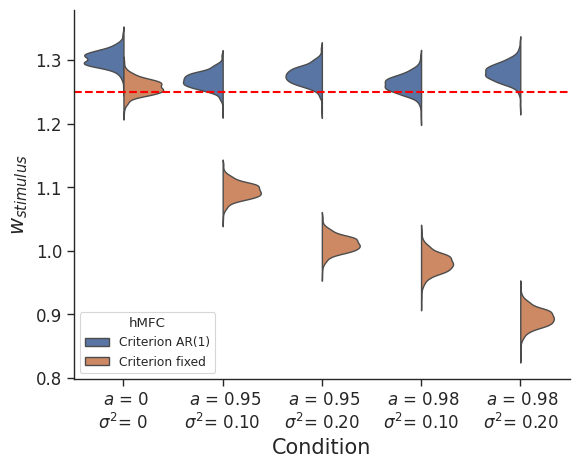

In [88]:
""" 
Plotting posteriors psychometric slope 
"""

plt.figure()
sns.violinplot(data=df_posterior, x="condition", y="posterior_evidence", hue="criterion_estimated",
               split=True, inner=None)
plt.axhline(y=1.25, color='red', linestyle='--')
plt.xlabel('Condition', fontsize=15)
plt.ylabel(r"$w_{stimulus}$", fontsize=15)
plt.yticks(fontsize=12)
plt.xticks(fontsize=12)
plt.legend(title='hMFC',loc='lower left')
plt.savefig("correction_w_stimulus.png", transparent=True, dpi=600)
plt.show()

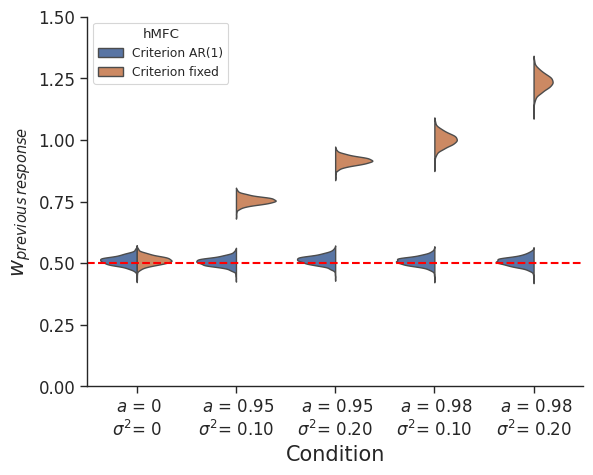

In [89]:
""" 
Plotting posteriors previous response 
"""

plt.figure()
plt.axhline(y=mu_w[1], color='red', linestyle='--')
sns.violinplot(data=df_posterior, x="condition", y="posterior_prevresp", hue="criterion_estimated",
               split=True, inner=None, fill=True)
plt.xlabel('Condition', fontsize=15)
plt.ylabel(r"$w_{previous \,response}$", fontsize=15)
plt.yticks(fontsize=12)
plt.xticks(fontsize=12)
plt.ylim(0,1.5)
plt.legend(title='hMFC',loc='upper left')
plt.savefig("correction_w_prevresp.png", transparent=True, dpi=600)
plt.show()

In [32]:
jnp.mean(true_params_fixed['w'][:,0])

Array(1.2334049, dtype=float32)

/tmp/ipykernel_1521510/1712288048.py:10: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, p = spearmanr(true_params_fixed['mu_x'], jnp.mean(posterior_samples_mu_x_fixed[burn_in:], axis=0))


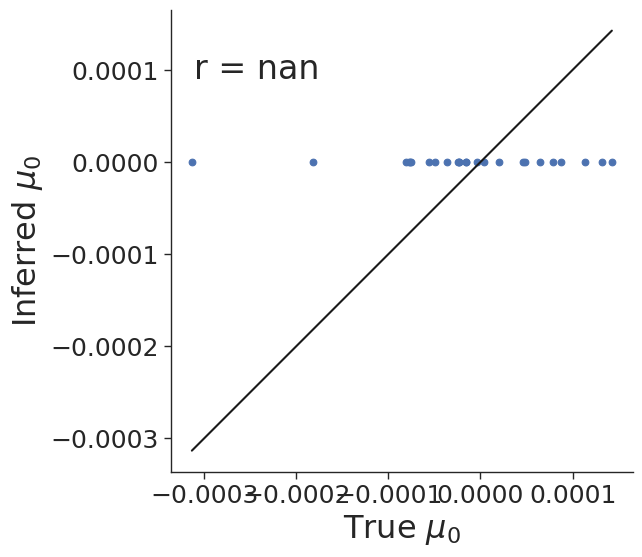

In [43]:
mu_x_min = min(true_params_fixed['mu_x'].min(), jnp.mean(posterior_samples_mu_x_fixed[burn_in:], axis=0).min())
mu_x_max = max(true_params_fixed['mu_x'].max(), jnp.mean(posterior_samples_mu_x_fixed[burn_in:], axis=0).max())

plt.figure(figsize=(8, 6))
plt.scatter(true_params_fixed['mu_x'], jnp.mean(posterior_samples_mu_x_fixed[burn_in:], axis=0))
plt.plot([mu_x_min, mu_x_max], [mu_x_min, mu_x_max], '-k')
plt.xlabel("True $\mu_0$")
plt.ylabel("Inferred $\mu_0$")
plt.gca().set_aspect(1.0)
r, p = spearmanr(true_params_fixed['mu_x'], jnp.mean(posterior_samples_mu_x_fixed[burn_in:], axis=0))
plt.annotate('r = {:.2f}'.format(r), xy=(0.05, 0.85), xycoords='axes fraction')
sns.despine()
plt.show()


In [42]:
true_params_fixed['w'].shape

(25, 2)

/tmp/ipykernel_1521510/3940475744.py:5: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, p = spearmanr(true_params_fixed['w'][:,1], jnp.mean(posterior_samples_mu_x_fixed[burn_in:], axis=0))


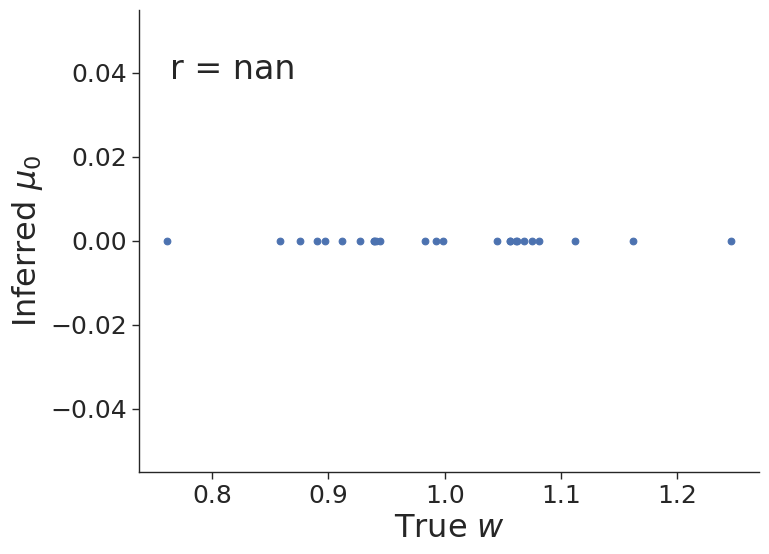

In [45]:

plt.figure(figsize=(8, 6))
plt.scatter(true_params_fixed['w'][:,1], jnp.mean(posterior_samples_mu_x_fixed[burn_in:], axis=0))
plt.xlabel("True $w$")
plt.ylabel("Inferred $\mu_0$")
r, p = spearmanr(true_params_fixed['w'][:,1], jnp.mean(posterior_samples_mu_x_fixed[burn_in:], axis=0))
plt.annotate('r = {:.2f}'.format(r), xy=(0.05, 0.85), xycoords='axes fraction')
sns.despine()
plt.show()


/tmp/ipykernel_1521510/3251154040.py:10: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, p = spearmanr(true_params_LL['w'][:,1], jnp.mean(posterior_samples_mu_x_LL[burn_in:], axis=0))


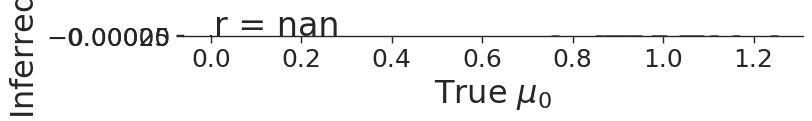

In [46]:
mu_x_min = min(true_params_LL['mu_x'].min(), jnp.mean(posterior_samples_mu_x_LL[burn_in:], axis=0).min())
mu_x_max = max(true_params_LL['mu_x'].max(), jnp.mean(posterior_samples_mu_x_LL[burn_in:], axis=0).max())

plt.figure(figsize=(8, 6))
plt.scatter(true_params_LL['w'][:,1], jnp.mean(posterior_samples_mu_x_LL[burn_in:], axis=0))
plt.plot([mu_x_min, mu_x_max], [mu_x_min, mu_x_max], '-k')
plt.xlabel("True $\mu_0$")
plt.ylabel("Inferred $w$")
plt.gca().set_aspect(1.0)
r, p = spearmanr(true_params_LL['w'][:,1], jnp.mean(posterior_samples_mu_x_LL[burn_in:], axis=0))
plt.annotate('r = {:.2f}'.format(r), xy=(0.05, 0.85), xycoords='axes fraction')
sns.despine()
plt.show()


In [32]:
"""
Create dataframe 
"""
subject_est_evidence_CF = np.concatenate((jnp.mean(posterior_w_fixed[:burn_in,:,1], axis=0), jnp.mean(posterior_w_LL[:burn_in,:,1], axis=0), jnp.mean(posterior_w_LH[:burn_in,:,1], axis=0), jnp.mean(posterior_w_HL[:burn_in,:,1], axis=0), jnp.mean(posterior_w_HH[:burn_in,:,1], axis=0)))
subject_est_evidence_noCF = np.concatenate((jnp.mean(posterior_w_fixed_no_est_CF[:burn_in,:,1], axis=0), jnp.mean(posterior_w_LL_no_est_CF[:burn_in,:,1], axis=0), jnp.mean(posterior_w_LH_no_est_CF[:burn_in,:,1], axis=0), jnp.mean(posterior_w_HL_no_est_CF[:burn_in,:,1], axis=0), jnp.mean(posterior_w_HH_no_est_CF[:burn_in,:,1], axis=0)))
subject_est_evidence = np.concatenate((subject_est_evidence_CF,subject_est_evidence_noCF))

subject_est_prevresp_CF = np.concatenate((jnp.mean(posterior_w_fixed[:burn_in,:,2], axis=0), jnp.mean(posterior_w_LL[:burn_in,:,2], axis=0), jnp.mean(posterior_w_LH[:burn_in,:,2], axis=0), jnp.mean(posterior_w_HL[:burn_in,:,2], axis=0), jnp.mean(posterior_w_HH[:burn_in,:,2], axis=0)))
subject_est_prevresp_noCF = np.concatenate((jnp.mean(posterior_w_fixed_no_est_CF[:burn_in,:,2], axis=0), jnp.mean(posterior_w_LL_no_est_CF[:burn_in,:,2], axis=0), jnp.mean(posterior_w_LH_no_est_CF[:burn_in,:,2], axis=0), jnp.mean(posterior_w_HL_no_est_CF[:burn_in,:,2], axis=0), jnp.mean(posterior_w_HH_no_est_CF[:burn_in,:,2], axis=0)))
subject_est_prevresp = np.concatenate((subject_est_prevresp_CF,subject_est_prevresp_noCF))

condition = np.tile(np.repeat([" $a$ = 0\n$\sigma^2$= 0"," $a$ = 0.95\n$\sigma^2$= 0.10", " $a$ = 0.95\n$\sigma^2$= 0.20", " $a$ = 0.98\n$\sigma^2$= 0.10", " $a$ = 0.98\n$\sigma^2$= 0.20"], len(jnp.mean(posterior_w_fixed[:burn_in,:,1], axis=0))),2)
criterion_estimated = np.repeat(["Criterion estimated","Criterion not estimated"], 5*len(jnp.mean(posterior_w_fixed[:burn_in,:,1], axis=0)))

df_subject_est = pd.DataFrame({"subject_est_evidence": subject_est_evidence, "subject_est_prevresp": subject_est_prevresp, "condition": condition, "criterion_estimated" : criterion_estimated})

NameError: name 'posterior_w_fixed' is not defined

In [ ]:
"""
Plotting individual estimates for slope (can't get the same color mapping as figure 1c)
"""

colors = ["black","#2c456b","#3c649f", "#4779c4", "#83aff0"]

sns.stripplot(
    data=df_subject_est, x="condition", hue="criterion_estimated", y="subject_est_evidence",
    alpha=.3, palette=colors, dodge=True
)

plt.axhline(y=1.25, color='red', linestyle='--')
plt.xlabel('Condition', fontsize=15)
plt.ylabel(r"$\beta_{stimulus}$", fontsize=15)
plt.yticks(fontsize=15)
plt.xticks(fontsize=13)
plt.legend(title='',loc='lower left')
plt.show()

In [ ]:
"""
Plotting individual estimates for previous response (can't get the same color mapping as figure 1c)
"""

sns.stripplot(
    data=df_subject_est, x="condition", hue="criterion_estimated", y="subject_est_prevresp",
    alpha=.3, palette=colors, dodge=True
)

plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Condition', fontsize=15)
plt.ylabel(r"$\beta_{previous \,response}$", fontsize=15)
plt.yticks(fontsize=15)
plt.xticks(fontsize=13)
plt.legend(title='',loc='upper left')
plt.show()